# 06_metacell_myeloid only

In [534]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [535]:
%matplotlib inline

In [536]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scanpy as sc
from pathlib import Path

In [537]:
adata = sc.read_h5ad("results/06/zmanseq_myeloid_cells.h5ad")
madata = sc.read_h5ad("results/06/zmanseq_myeloid_metacells.h5ad")

In [538]:
madata.X.sum(axis=1).shape # normalized to 1. 

(72, 1)

In [539]:
madata.obs['total_umis'].hist()
plt.xlabel('Total UMIs per metacell')
plt.ylabel('Number of metacells')
plt.title('Distribution of total UMIs per metacell')
plt.show()
madata.obs['total_umis'].describe()


count        72.000000
mean     154873.222222
std       67634.008742
min       32693.000000
25%      108690.250000
50%      139580.500000
75%      184649.500000
max      319596.000000
Name: total_umis, dtype: float64

In [540]:
madata.obs['grouped'].hist()
plt.xlabel('Grouped cells per metacell')
plt.ylabel('Number of metacells')
plt.title('Distribution of grouped cells per metacell')
plt.show()
madata.obs['grouped'].describe()


count     72.000000
mean      99.652778
std       34.577188
min       19.000000
25%       76.750000
50%       98.500000
75%      115.000000
max      199.000000
Name: grouped, dtype: float64

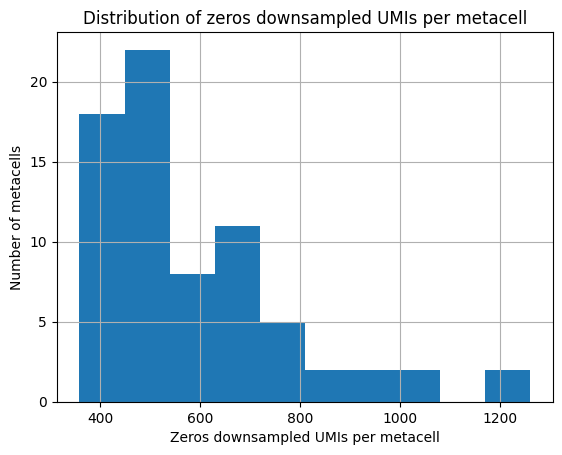

count      72.000000
mean      582.638889
std       188.207281
min       359.000000
25%       451.250000
50%       519.500000
75%       658.000000
max      1260.000000
Name: __zeros_downsample_umis, dtype: float64

In [16]:
madata.obs['__zeros_downsample_umis'].hist()
plt.xlabel('Zeros downsampled UMIs per metacell')
plt.ylabel('Number of metacells')
plt.title('Distribution of zeros downsampled UMIs per metacell')
plt.show()
madata.obs['__zeros_downsample_umis'].describe()


## MC cell type

In [541]:
mc_to_annot_counts_df = adata.obs.groupby(['metacell_name', 'cluster_colors']).size().unstack()
mc_to_annot_pct_df = mc_to_annot_counts_df / mc_to_annot_counts_df.sum(axis=1).values[:, np.newaxis] # rowwise

/tmp/ipykernel_1659146/2844306787.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mc_to_annot_counts_df = adata.obs.groupby(['metacell_name', 'cluster_colors']).size().unstack()


In [542]:
mc_to_annot_pct_df

cluster_colors,Acp5_TAM,Arg1_TAM,Gpnmb_TAM,MigDC,MoMac1,MoMac2,MonDC,Monocytes,cDC1,cDC2,pDC
metacell_name,,,,,,,,,,,
M0.22,0.009524,0.952381,0.038095,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
M1.91,0.981982,0.018018,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
M2.23,0.280000,0.013333,0.000000,0.000000,0.653333,0.026667,0.000000,0.026667,0.000000,0.000000,0.000000
M3.06,0.034483,0.793103,0.017241,0.000000,0.017241,0.137931,0.000000,0.000000,0.000000,0.000000,0.000000
M4.31,0.000000,0.214286,0.071429,0.000000,0.071429,0.642857,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
M68.22,0.000000,0.981982,0.018018,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
M69.75,0.346154,0.192308,0.115385,0.000000,0.192308,0.115385,0.000000,0.038462,0.000000,0.000000,0.000000
M70.00,0.105263,0.263158,0.000000,0.000000,0.000000,0.526316,0.000000,0.052632,0.000000,0.052632,0.000000


In [545]:
%matplotlib inline

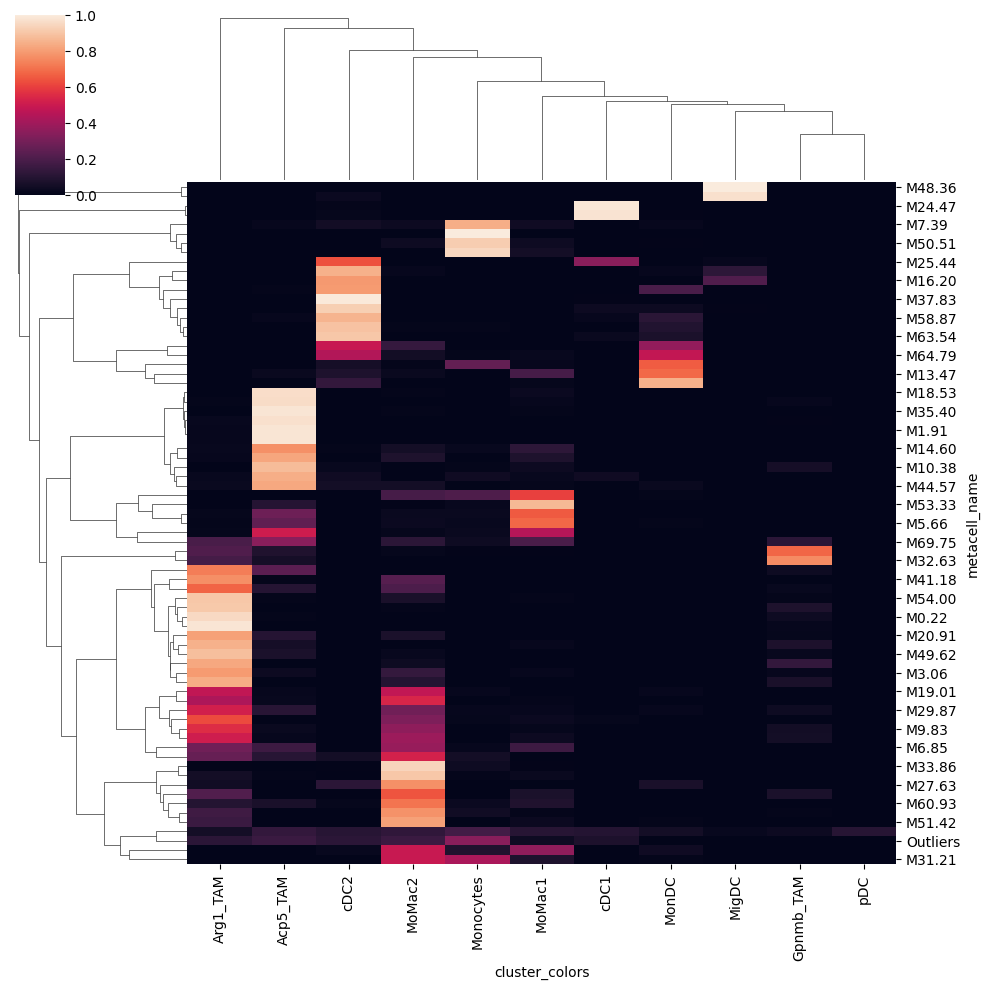

In [547]:
sns.clustermap(mc_to_annot_pct_df)

In [548]:
mc_to_annot_pct_df.max(axis=1)

metacell_name
M0.22       0.952381
M1.91       0.981982
M2.23       0.653333
M3.06       0.793103
M4.31       0.642857
              ...   
M68.22      0.981982
M69.75      0.346154
M70.00      0.526316
M71.75      0.177083
Outliers    0.346154
Length: 73, dtype: float64

In [549]:
madata.obs['metacell_cell_type'] = mc_to_annot_pct_df.idxmax(axis=1).loc[madata.obs_names]
madata.obs['metacell_cell_type_pct'] = mc_to_annot_pct_df.max(axis=1).loc[madata.obs_names]

In [550]:
madata.obs['sc_x'] = adata.obs.groupby(['metacell_name'])['sc_x'].median()
madata.obs['sc_y'] = adata.obs.groupby(['metacell_name'])['sc_y'].median()

/tmp/ipykernel_1659146/3043740112.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  madata.obs['sc_x'] = adata.obs.groupby(['metacell_name'])['sc_x'].median()
/tmp/ipykernel_1659146/3043740112.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  madata.obs['sc_y'] = adata.obs.groupby(['metacell_name'])['sc_y'].median()


In [551]:
myeloid_cell_type_colors = {
    'Arg1_TAM': "mediumorchid", 
    'Acp5_TAM': "slateblue", 
    'MoMac1': "tab:blue", 
    'MoMac2': "tab:red", 
    'Monocytes': "tab:orange", 
    'cDC2': "goldenrod", 
    'MonDC': "gold", 
    'Gpnmb_TAM': "lightblue", 
    'cDC1': "darkkhaki", 
    'MigDC': "tab:brown",
    'transitory': "teal",
    "pDC": "tab:green",
}


In [555]:
madata.obsp['connectivities']

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1384 stored elements and shape (72, 72)>

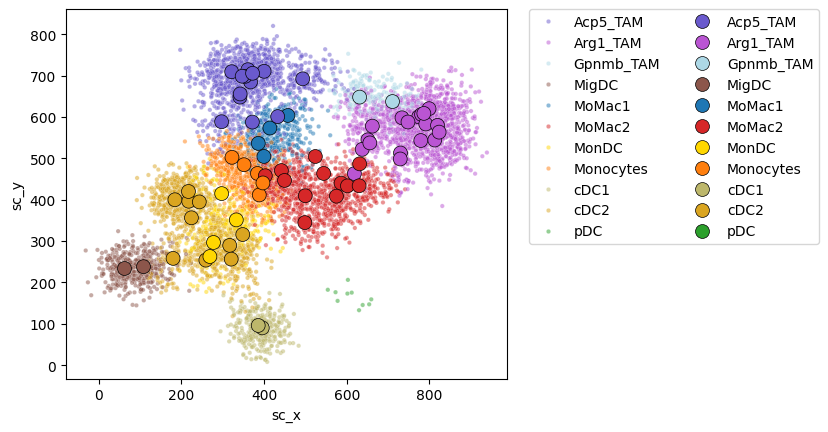

In [552]:
sns.scatterplot(data=adata.obs, x='sc_x', y='sc_y', hue='cluster_colors', s=10, palette=myeloid_cell_type_colors, alpha=0.5)
sns.scatterplot(
    data=madata.obs, x='sc_x', y='sc_y', hue='metacell_cell_type', 
    s=100, palette=myeloid_cell_type_colors, edgecolor='black', linewidth=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=2)
plt.gca().set_aspect('equal')
plt.show()


## Treatment enrichment

Fraction centered on 0.5

In [556]:
# treatment enrichment
metacell_treatment_counts_df = adata.obs.groupby(['metacell_name', 'Treatment']).size().unstack()
metacell_treatment_counts_df['enrichment'] = 0.5 - (metacell_treatment_counts_df['aTrem2'] / metacell_treatment_counts_df.sum(axis=1))

/tmp/ipykernel_1659146/279601780.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metacell_treatment_counts_df = adata.obs.groupby(['metacell_name', 'Treatment']).size().unstack()


In [557]:
madata.obs[metacell_treatment_counts_df.columns] = metacell_treatment_counts_df.loc[madata.obs_names].values

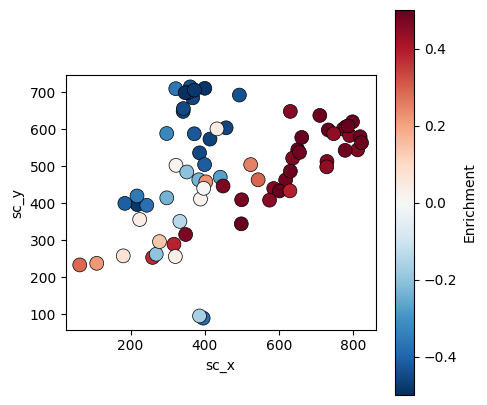

In [558]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(
    data=madata.obs, x='sc_x', y='sc_y', hue='enrichment', 
    s=100, palette='RdBu_r', edgecolor='black', linewidth=0.5, hue_norm=(-0.5, 0.5), legend=False, ax=ax)
# cmap
cmap = plt.cm.RdBu_r
norm = Normalize(vmin=-0.5, vmax=0.5)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, orientation='vertical', label='Enrichment', ax=ax)
ax.set_aspect('equal')
plt.show()

In [559]:
metacell_time_bin_count_df = adata.obs.groupby(['metacell_name', 'time_assignment']).size().unstack()

time_bins = ["12H", "24H", "36H", "48H"]
metacell_time_bin_pct_df = metacell_time_bin_count_df[time_bins] / metacell_time_bin_count_df[time_bins].sum(axis=1).values[:, np.newaxis] # rowwis

/tmp/ipykernel_1659146/1961867476.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metacell_time_bin_count_df = adata.obs.groupby(['metacell_name', 'time_assignment']).size().unstack()


In [560]:
metacell_time_bin_cum_pct_df = metacell_time_bin_pct_df.cumsum(axis=1)
metacell_time_bin_cum_pct_df['0H'] = 0.0
metacell_time_bin_cum_pct_df = metacell_time_bin_cum_pct_df[['0H', '12H', '24H', '36H']]
metacell_time_bin_cum_pct_df.loc[madata.obs_names, 'metacell_cell_type'] = madata.obs['metacell_cell_type']

In [561]:
metacell_time_bin_cum_pct_df

time_assignment,0H,12H,24H,36H,metacell_cell_type
metacell_name,,,,,
M0.22,0.0,0.142857,0.769231,1.000000,Arg1_TAM
M1.91,0.0,0.352941,0.627451,1.000000,Acp5_TAM
M2.23,0.0,0.775510,0.857143,1.000000,MoMac1
M3.06,0.0,0.108108,0.837838,0.972973,Arg1_TAM
M4.31,0.0,0.348837,0.767442,0.953488,MoMac2
...,...,...,...,...,...
M68.22,0.0,0.072289,0.674699,0.951807,Arg1_TAM
M69.75,0.0,0.214286,0.785714,1.000000,Acp5_TAM
M70.00,0.0,0.277778,0.833333,1.000000,MoMac2


/tmp/ipykernel_1659146/4223379879.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (cell_type, df) in enumerate(metacell_time_bin_cum_pct_df.groupby('metacell_cell_type')):
/data/ClaudiaC/envs/zmanr_env/lib/python3.13/site-packages/seaborn/relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
/data/ClaudiaC/envs/zmanr_env/lib/python3.13/site-packages/seaborn/relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or 

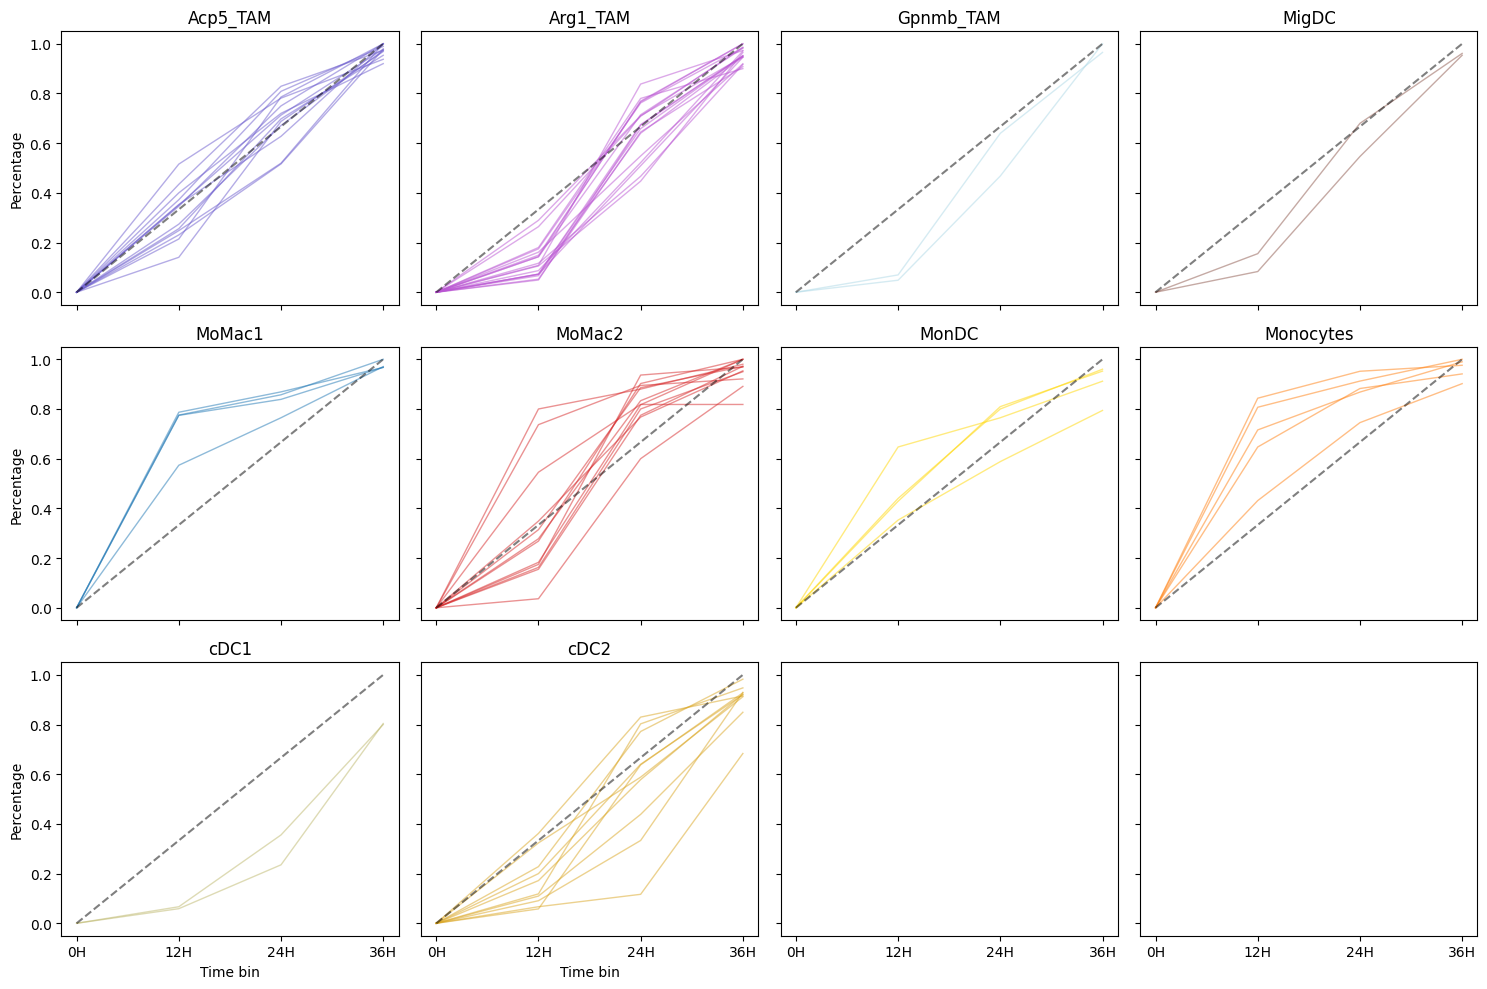

In [563]:
cell_type_counts = metacell_time_bin_cum_pct_df['metacell_cell_type'].value_counts()
cell_types_w_data = cell_type_counts[cell_type_counts > 0].index.tolist()
n_cols = 4
n_rows = (len(cell_types_w_data) + n_cols - 1) // n_cols 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10), sharex=True, sharey=True)
flat_axes = axes.flatten()
for i, (cell_type, df) in enumerate(metacell_time_bin_cum_pct_df.groupby('metacell_cell_type')):
    if cell_type not in cell_types_w_data:
        continue
    ax = flat_axes[i]
    sns.lineplot(
        data=df.reset_index().set_index(
            ["metacell_name", "metacell_cell_type"]
    ).stack().reset_index(name='cum_pct'), 
        x='time_assignment', y='cum_pct', units="metacell_name",
        estimator=None, 
        hue='metacell_cell_type', linewidth=1, alpha=0.5, palette=myeloid_cell_type_colors,
        ax=ax, legend=False
    )
    ax.set_xlabel('Time bin')
    ax.set_ylabel('Percentage')
    ax.set_title(f'{cell_type}')
    ax.plot([0, 3], [0, 1], 'k--', alpha=0.5)
plt.tight_layout()
plt.show()



## Calculate raw cTET

In [565]:
from sklearn import metrics

time_bins = ["0H", "12H", "24H", "36H"]
metacell_time_bin_cum_pct_df['AUC'] = metacell_time_bin_cum_pct_df.apply(
    lambda r: metrics.auc(np.arange(len(r[time_bins])), r[time_bins].values), axis=1
)
metacell_time_bin_cum_pct_df['norm_AUC'] = (metacell_time_bin_cum_pct_df['AUC'] - metacell_time_bin_cum_pct_df['AUC'].min()) / (metacell_time_bin_cum_pct_df['AUC'].max() - metacell_time_bin_cum_pct_df['AUC'].min())
metacell_time_bin_cum_pct_df['cTET'] = 1 - metacell_time_bin_cum_pct_df['norm_AUC']
metacell_time_bin_cum_pct_df

time_assignment,0H,12H,24H,36H,metacell_cell_type,AUC,norm_AUC,cTET
metacell_name,,,,,,,,
M0.22,0.0,0.142857,0.769231,1.000000,Arg1_TAM,1.412088,0.504563,0.495437
M1.91,0.0,0.352941,0.627451,1.000000,Acp5_TAM,1.480392,0.543413,0.456587
M2.23,0.0,0.775510,0.857143,1.000000,MoMac1,2.132653,0.914409,0.085591
M3.06,0.0,0.108108,0.837838,0.972973,Arg1_TAM,1.432432,0.516134,0.483866
M4.31,0.0,0.348837,0.767442,0.953488,MoMac2,1.593023,0.607476,0.392524
...,...,...,...,...,...,...,...,...
M68.22,0.0,0.072289,0.674699,0.951807,Arg1_TAM,1.222892,0.396950,0.603050
M69.75,0.0,0.214286,0.785714,1.000000,Acp5_TAM,1.500000,0.554566,0.445434
M70.00,0.0,0.277778,0.833333,1.000000,MoMac2,1.611111,0.617764,0.382236


/tmp/ipykernel_1659146/3929642340.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (cell_type, df) in enumerate(metacell_time_bin_cum_pct_df.groupby('metacell_cell_type')):


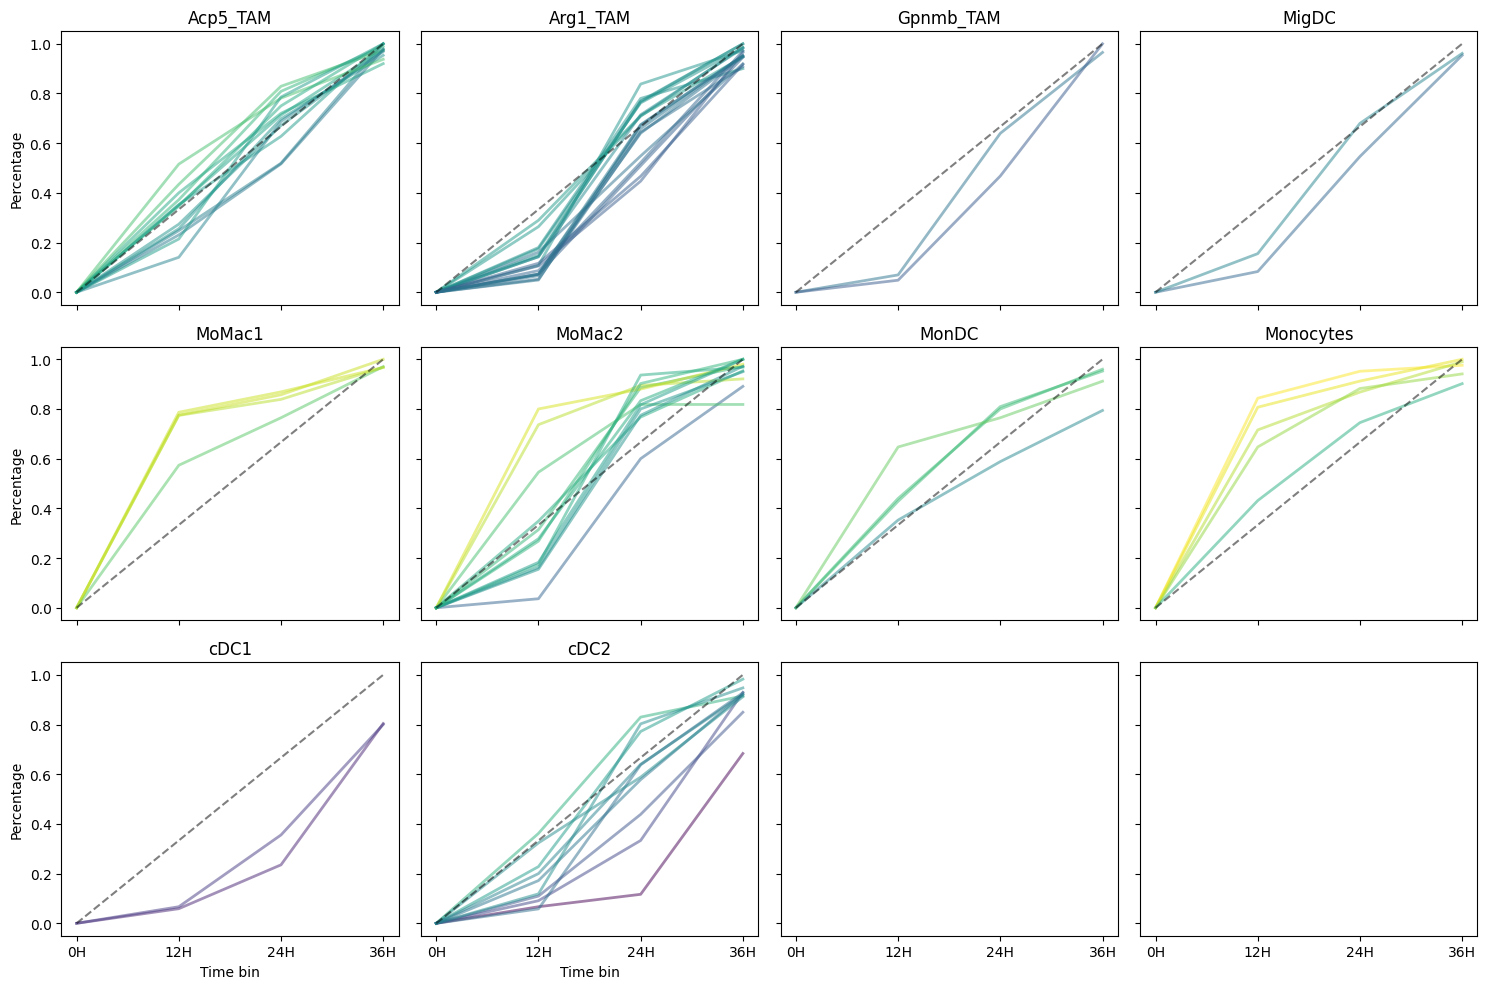

In [566]:
cell_type_counts = metacell_time_bin_cum_pct_df['metacell_cell_type'].value_counts()
cell_types_w_data = cell_type_counts[cell_type_counts > 0].index.tolist()
n_cols = 4
n_rows = (len(cell_types_w_data) + n_cols - 1) // n_cols 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10), sharex=True, sharey=True)
flat_axes = axes.flatten()

time_bins = ["0H", "12H", "24H", "36H"]

from matplotlib.colors import Normalize
norm = Normalize(vmin=0, vmax=1)
cmap = plt.cm.viridis_r
for i, (cell_type, df) in enumerate(metacell_time_bin_cum_pct_df.groupby('metacell_cell_type')):
    if cell_type not in cell_types_w_data:
        continue
    ax = flat_axes[i]
    for j, r in df.iterrows():

        sns.lineplot(
            x=time_bins, y=r[time_bins],  
            color=cmap(r['cTET']), linewidth=2, alpha=0.5,
            ax=ax, legend=False
        )
   
    ax.set_xlabel('Time bin')
    ax.set_ylabel('Percentage')
    ax.set_title(f'{cell_type}')
    ax.plot([0, 3], [0, 1], 'k--', alpha=0.5)
plt.tight_layout()
plt.show()



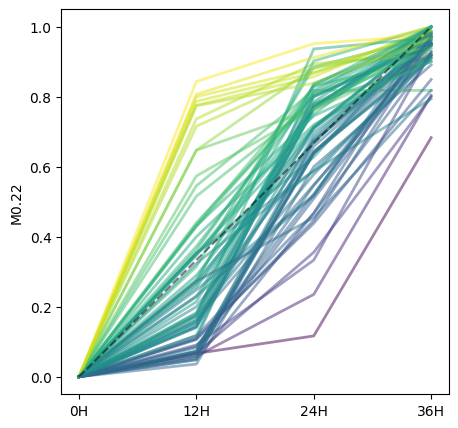

In [567]:
fig, ax = plt.subplots(figsize=(5, 5))
for j, r in metacell_time_bin_cum_pct_df.iterrows():

    sns.lineplot(
        x=time_bins, y=r[time_bins],  
        color=cmap(r['cTET']), linewidth=2, alpha=0.5,
        ax=ax, legend=False
    )
ax.plot([0, 3], [0, 1], 'k--', alpha=0.5)
plt.show()

Estimate the total exposure time assuming a constant infiltration rate

In [568]:
# time_interval = 12
# # invert the AUC shift by half the time interval to get the equivalent stepwise AUC <-- wrong
# metacell_time_bin_cum_pct_df['AUC_time_adj'] = (3 - metacell_time_bin_cum_pct_df['AUC']) * time_interval + (time_interval / 2) 

Estimating the absolute duration
- Interval $I$ (12)
- True duration: $D$
- $D/I$ Duration in interval units
- At least for initial states, I want to get the ratio of the frequency between adjacent intervals. 
- For a starting state, suppose the duration exceeds $2I$. Then I expect the ratio of the frequency between $0I, 1I$ and $1I, 2I$ to be equal since we evenly sample the interval. The first (? or largest)  

- basically these fractions are not mutually exclusive

In [569]:
myeloid_cell_type_colors["nan"] = 'gray'

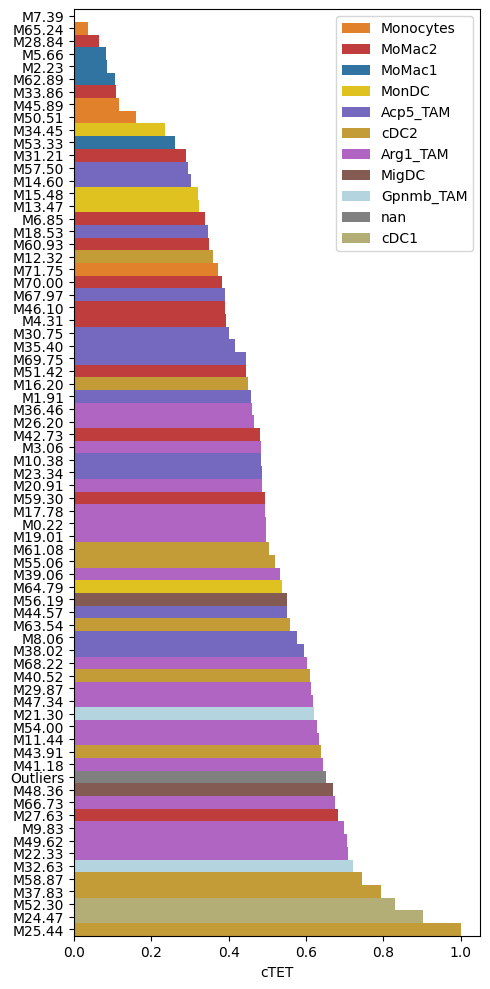

In [571]:
sorted_df = metacell_time_bin_cum_pct_df.sort_values('cTET', ascending=True).reset_index()

sorted_df['metacell_name'] = sorted_df['metacell_name'].astype(str)
sorted_df['metacell_cell_type'] = sorted_df['metacell_cell_type'].astype(str)

fig, ax = plt.subplots(figsize=(5, 10))
sns.barplot(
    x=sorted_df['cTET'].values, y=sorted_df['metacell_name'].values, 
    hue=sorted_df['metacell_cell_type'].values, width=1, linewidth=0, palette=myeloid_cell_type_colors,
    order=sorted_df['metacell_name'].tolist(), ax=ax
)
plt.xlabel('cTET')
plt.tight_layout()
plt.show()



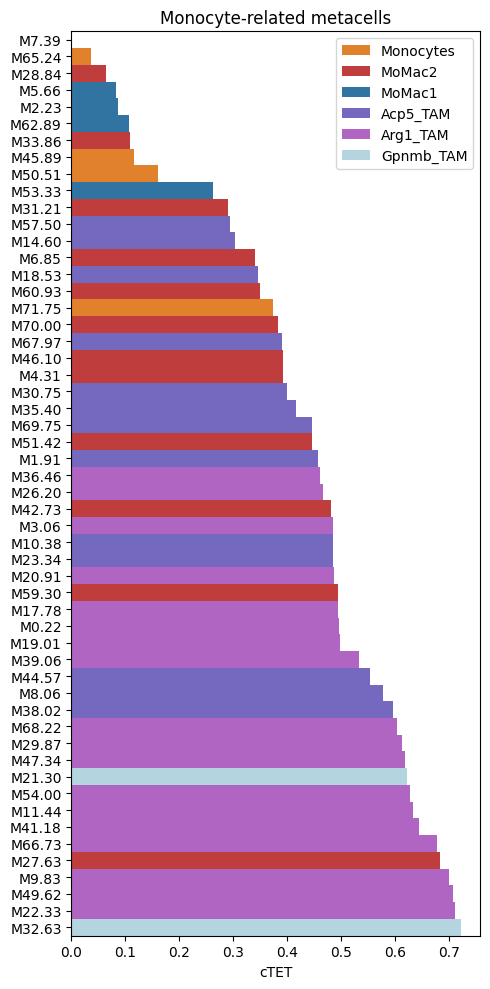

In [572]:
mo_types = ["Monocytes", "MoMac1", "MoMac2", "Gpnmb_TAM", "Arg1_TAM", "Acp5_TAM"]
mo_sorted_df = sorted_df[sorted_df['metacell_cell_type'].isin(mo_types)]

fig, ax = plt.subplots(figsize=(5, 10))
sns.barplot(
    x=mo_sorted_df['cTET'].values, y=mo_sorted_df['metacell_name'].values, 
    hue=mo_sorted_df['metacell_cell_type'].values, width=1, linewidth=0, palette=myeloid_cell_type_colors,
    order=mo_sorted_df['metacell_name'].tolist(), ax=ax
)
plt.xlabel('cTET')
plt.title('Monocyte-related metacells')
plt.tight_layout()
plt.show()


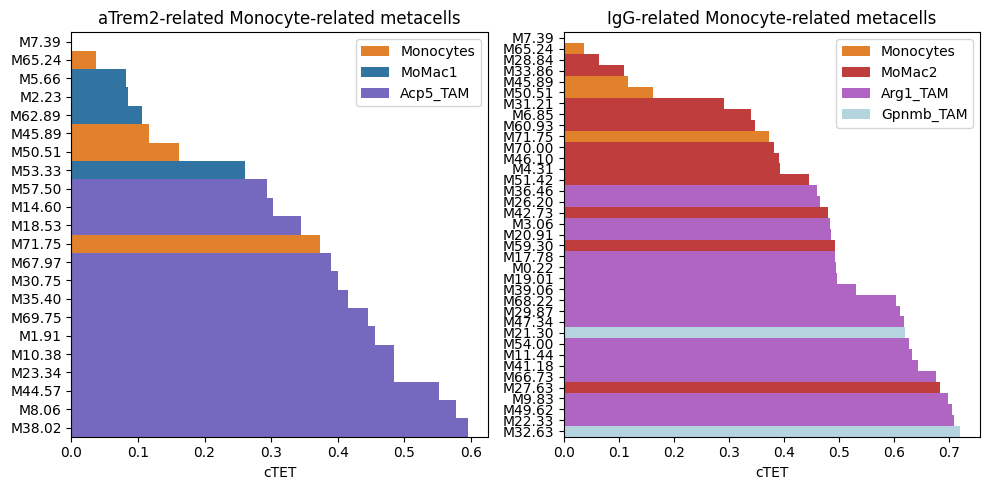

In [574]:
atrem_mo_types = ["Monocytes", "MoMac1", "Acp5_TAM"]
atrem_mo_sorted_df = sorted_df[sorted_df['metacell_cell_type'].isin(atrem_mo_types)]

igg_mo_types = ["Monocytes", "MoMac2", "Gpnmb_TAM", "Arg1_TAM", ]
igg_mo_sorted_df = sorted_df[sorted_df['metacell_cell_type'].isin(igg_mo_types)]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for i, (df_name, df) in enumerate(({"aTrem2":atrem_mo_sorted_df, "IgG":igg_mo_sorted_df}).items()):
    sns.barplot(
        x=df['cTET'].values, y=df['metacell_name'].values, 
        hue=df['metacell_cell_type'].values, width=1, linewidth=0, palette=myeloid_cell_type_colors,
        order=df['metacell_name'].tolist(), ax=ax[i]
    )
    ax[i].set_xlabel('cTET')
    ax[i].set_title(f'{df_name}-related Monocyte-related metacells')
plt.tight_layout()
plt.show()


/tmp/ipykernel_1659146/4125187545.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rank'] = df.reset_index().index
/tmp/ipykernel_1659146/4125187545.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['norm_rank'] = df['rank'] / len(df)
/tmp/ipykernel_1659146/4125187545.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

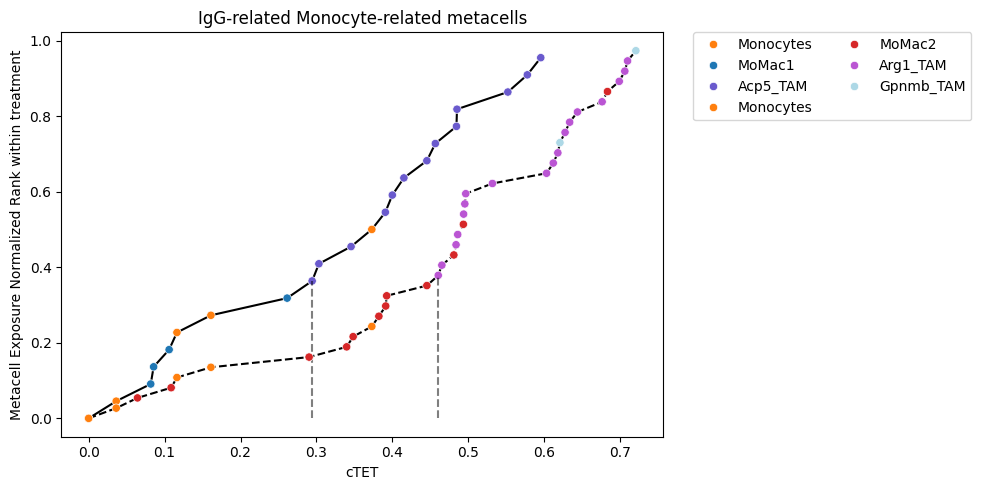

In [576]:
fig, ax = plt.subplots(figsize=(10, 5))

treatment_type_style = {"aTrem2": "solid", "IgG": "--"}
for i, (df_name, df) in enumerate(({"aTrem2":atrem_mo_sorted_df, "IgG":igg_mo_sorted_df}).items()):
    df['rank'] = df.reset_index().index
    df['norm_rank'] = df['rank'] / len(df)
    sns.lineplot(
        x=df['cTET'].values, y=df['norm_rank'].values, 
        color='black', linestyle=treatment_type_style[df_name],
        ax=ax, zorder=1
    )
    sns.scatterplot(
        x=df['cTET'].values, y=df['norm_rank'].values, 
        hue=df['metacell_cell_type'].values, palette=myeloid_cell_type_colors,
        ax=ax, zorder=2
    )
    # plot transition to final TAM state
    for _, r in df[df['metacell_cell_type'].str.contains('TAM')].iterrows():
        ax.plot([r['cTET'], r['cTET']], [0, r['norm_rank']], color='black', linestyle='--', alpha=0.5)
        break # first one

ax.set_xlabel('cTET')
ax.set_ylabel('Metacell Exposure Normalized Rank within treatment')
ax.set_title(f'{df_name}-related Monocyte-related metacells')
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=2)



plt.tight_layout()
plt.show()

Treating each metacell as a distinct state

## Smoothed cTET

Forcing cells with the same type to have more similar cTET

In [577]:
madata.obs[metacell_time_bin_cum_pct_df.columns] = metacell_time_bin_cum_pct_df.loc[madata.obs_names].values

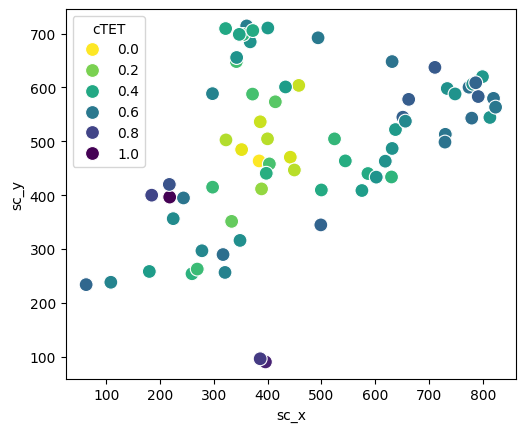

In [578]:
sns.scatterplot(data=madata.obs, x='sc_x', y='sc_y', hue='cTET', s=100, palette='viridis_r')
plt.gca().set_aspect('equal')
plt.show()


Sum the counts from the full adata object, then downsample

In [586]:
madata_cell_counts = np.zeros((madata.n_obs, madata.n_vars))
for i, mc in enumerate(madata.obs_names):
    madata_cell_counts[i, :] = adata[adata.obs.query('metacell_name == @mc').index, :].X.sum(axis=0)
madata_cell_counts.shape

(72, 27055)

In [596]:
from scipy.sparse import csr_matrix
import scipy.sparse as sp

In [591]:
madata.layers['freq'] = madata.X # frequency
madata.layers['total_umis'] = csr_matrix(madata_cell_counts)
madata.X = madata.layers['total_umis']

In [592]:
adata.obs['total_counts'].median()

np.float32(1235.0)

In [627]:
adata.obs['total_counts'].describe()

count     7201.000000
mean      1553.642212
std       1226.248535
min        301.000000
25%        742.000000
50%       1235.000000
75%       1994.000000
max      27104.000000
Name: total_counts, dtype: float64

In [ ]:
sc.pp.downsample_counts(madata, copy=False, counts_per_cell=int(adata.obs['total_counts'].median()))

In [598]:
madata

AnnData object with n_obs × n_vars = 72 × 27055
    obs: 'grouped', 'total_umis', '__zeros_downsample_umis', 'metacell_cell_type', 'metacell_cell_type_pct', 'sc_x', 'sc_y', 'IgG', 'aTrem2', 'enrichment', '0H', '12H', '24H', '36H', 'AUC', 'norm_AUC', 'cTET', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'lateral_gene', 'noisy_gene', 'selected_gene', 'log1p_mean_counts', 'log1p_total_counts'
    uns: '__name__', 'metacells_algorithm', 'neighbors', 'outliers'
    layers: 'total_umis', 'zeros', 'freq'
    obsp: 'connectivities', 'distances'

Using scanpy processing

In [597]:
sc.pp.calculate_qc_metrics(madata, inplace=True, log1p=True)

In [599]:
# Normalizing to median total counts
sc.pp.normalize_total(madata)
# Logarithmize the data
sc.pp.log1p(madata)

<Axes: >

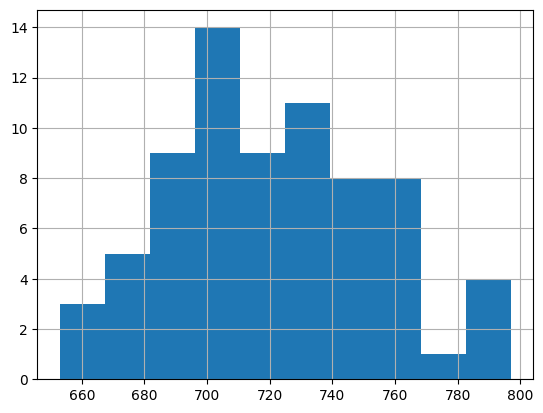

In [836]:
madata.obs['n_genes_by_counts'].hist()

Fairly low?

In [841]:
sc.pp.highly_variable_genes(madata, n_top_genes=1000)

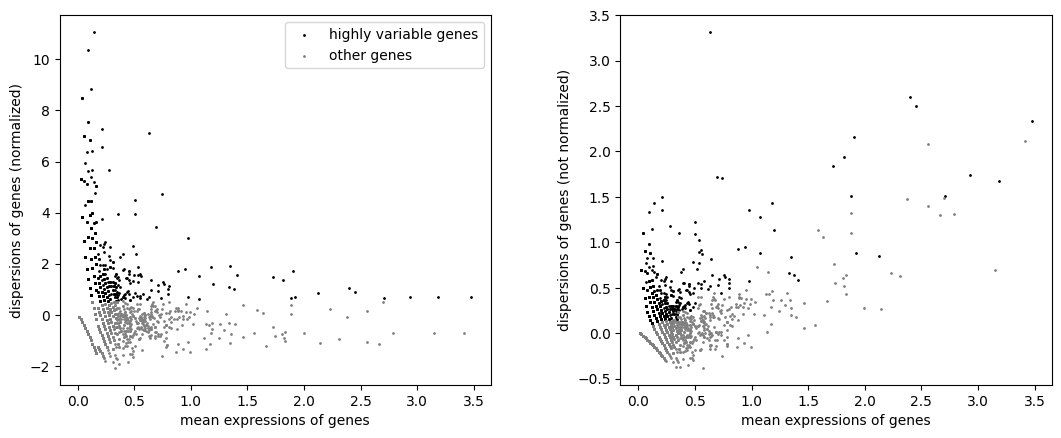

In [842]:
sc.pl.highly_variable_genes(madata)

In [603]:
madata[:, madata.var['highly_variable']].X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9848 stored elements and shape (72, 1001)>

In [604]:
madata.obs['AUC']

M0.22     1.412088
M1.91     1.480392
M2.23     2.132653
M3.06     1.432432
M4.31     1.593023
            ...   
M67.97    1.596154
M68.22    1.222892
M69.75         1.5
M70.00    1.611111
M71.75    1.627451
Name: AUC, Length: 72, dtype: object

# gene correlations with raw cTET

Get correlation vector for each gene and group

In [605]:
hvg_freq_sort_df = pd.DataFrame(
    madata[
        madata.obs.sort_values('AUC', ascending=False).index, 
        madata.var['highly_variable']
    ].X.toarray(), 
    index=madata.obs.sort_values('AUC', ascending=False).index, 
    columns=madata.var.query('highly_variable').index
)

In [606]:
hvg_freq_sort_df

,AC122235.1,AC124426.2,AC124744.2,AC134860.1,AC139579.1,AC151730.1,AC151971.3,AC153955.5,AC158239.2,AC159261.1,...,Zfp518b,Zfp677,Zfp706,Zkscan3,Zmiz1,Zmynd11,Zmynd15,Zufsp,Zyx,Zzef1
M7.39,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.693147,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
M65.24,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.693147,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.693147,0.000000
M28.84,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,1.386294,0.000000,0.000000
M5.66,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.693147,0.000000,0.693147
M2.23,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,1.098612,1.098612,0.0,0.0,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
M58.87,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,1.098612,0.0,...,0.0,0.0,0.693147,0.000000,0.0,0.0,0.0,0.000000,0.693147,0.000000
M37.83,0.693147,0.000000,1.098612,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,1.098612,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
M52.30,0.000000,0.000000,0.693147,0.0,0.0,0.0,0.000000,0.000000,0.693147,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.693147,0.693147,0.000000
M24.47,0.000000,0.693147,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.693147,0.000000,0.000000


/data/ClaudiaC/envs/zmanr_env/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


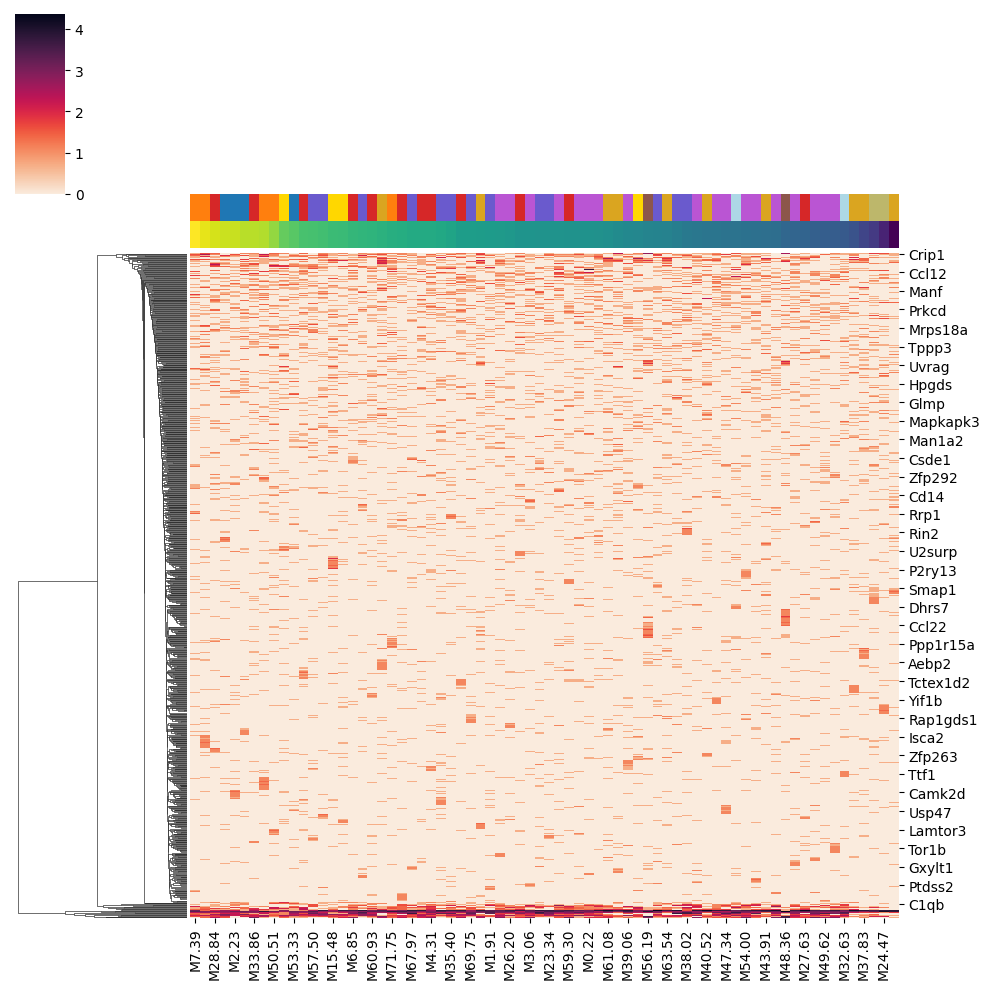

In [675]:
norm = Normalize(vmin=madata.obs.loc[hvg_freq_sort_df.index, 'AUC'].min(), vmax=madata.obs.loc[hvg_freq_sort_df.index, 'AUC'].max())
sns.clustermap(
    hvg_freq_sort_df.T, 
    col_cluster=False, col_colors=[
        madata.obs.loc[hvg_freq_sort_df.index, 'metacell_cell_type'].map(myeloid_cell_type_colors),
        madata.obs.loc[hvg_freq_sort_df.index, 'AUC'].apply(lambda x: plt.cm.viridis(norm(x)))
    ], 
    cmap='rocket_r'
)

/data/ClaudiaC/envs/zmanr_env/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


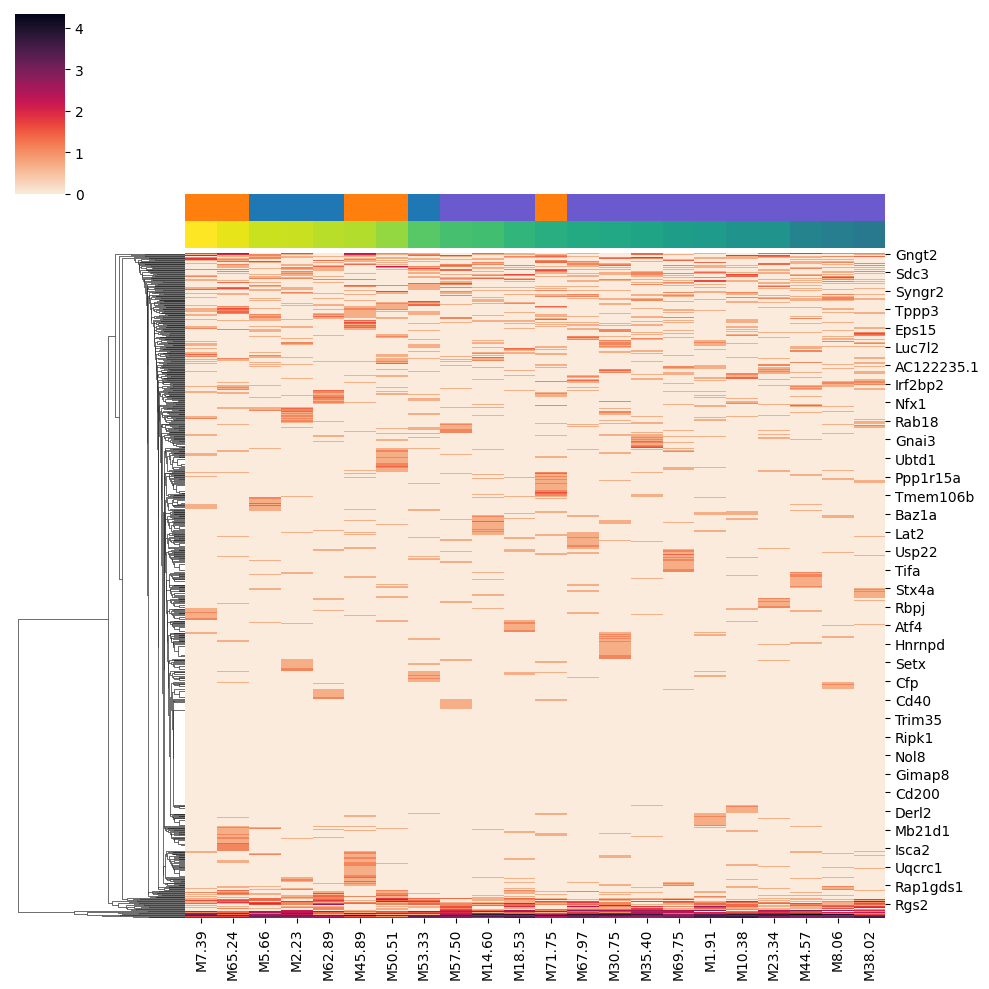

In [676]:
atrem_mo_types = ["Monocytes", "MoMac1", "Acp5_TAM"]
igg_mo_types = ["Monocytes", "MoMac2", "Gpnmb_TAM", "Arg1_TAM", ]

atrem_hvg_freq_sort_df = hvg_freq_sort_df.loc[
    madata.obs.query('metacell_cell_type in @atrem_mo_types').sort_values('AUC', ascending=False).index
]
norm = Normalize(vmin=madata.obs['AUC'].min(), vmax=madata.obs['AUC'].max())
sns.clustermap(
    atrem_hvg_freq_sort_df.T, 
    col_cluster=False, col_colors=[
        madata.obs.loc[atrem_hvg_freq_sort_df.index, 'metacell_cell_type'].map(myeloid_cell_type_colors),
        madata.obs.loc[atrem_hvg_freq_sort_df.index, 'AUC'].apply(lambda x: plt.cm.viridis(norm(x)))
    ],
    cmap='rocket_r'
)

/data/ClaudiaC/envs/zmanr_env/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


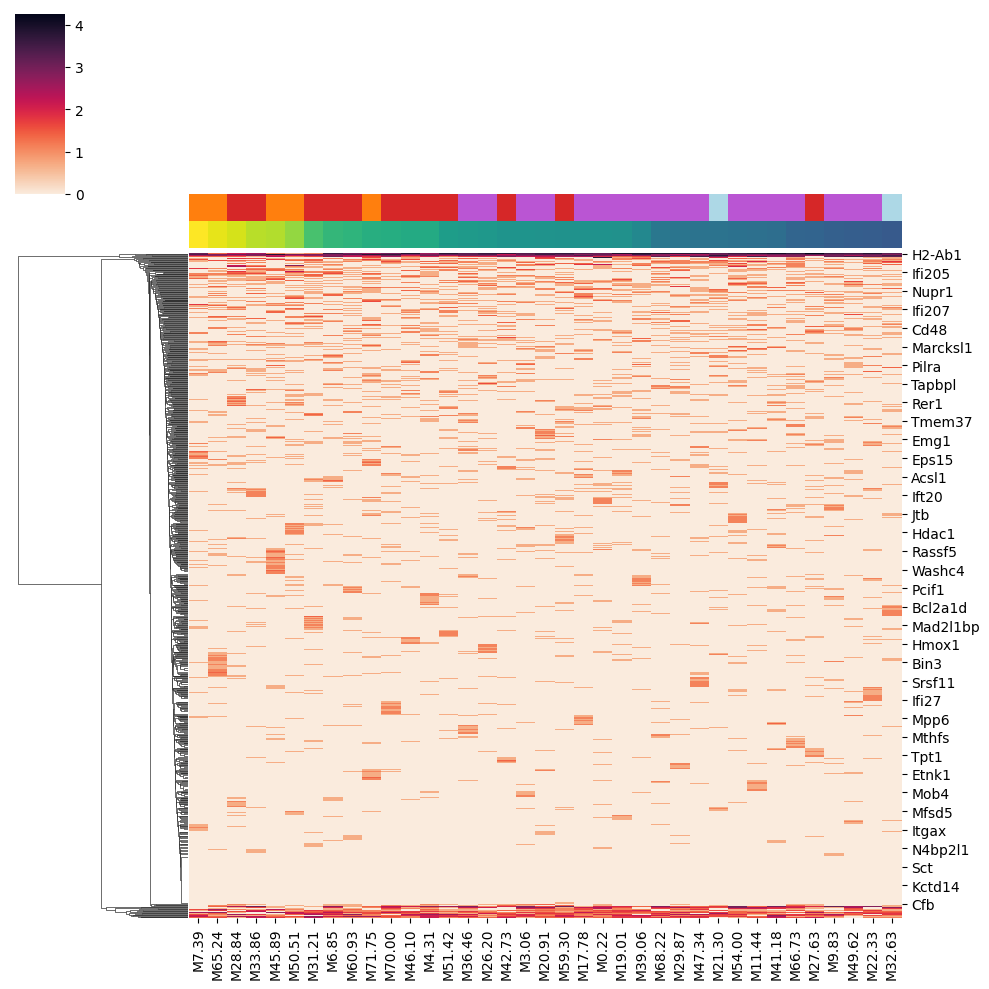

In [677]:
igg_hvg_freq_sort_df = hvg_freq_sort_df.loc[
    madata.obs.query('metacell_cell_type in @igg_mo_types').sort_values('AUC', ascending=False).index
]
norm = Normalize(vmin=madata.obs['AUC'].min(), vmax=madata.obs['AUC'].max())
sns.clustermap(
    igg_hvg_freq_sort_df.T, 
    col_cluster=False, col_colors=[
        madata.obs.loc[igg_hvg_freq_sort_df.index, 'metacell_cell_type'].map(myeloid_cell_type_colors),
        madata.obs.loc[igg_hvg_freq_sort_df.index, 'AUC'].apply(lambda x: plt.cm.viridis(norm(x)))
    ],
    cmap='rocket_r'
)

In [632]:
from scipy.stats import spearmanr

In [853]:
def get_spearman_df(hvg_freq_sort_df, madata, time_col="cTET"):
    spearman_df = pd.DataFrame(index=hvg_freq_sort_df.columns, columns=['spearman_r', 'p_value'])
    sort_mcs = madata.obs.loc[hvg_freq_sort_df.index].sort_values(time_col).index
    for gene in hvg_freq_sort_df.columns:
        s = spearmanr(madata.obs.loc[sort_mcs, time_col].values, hvg_freq_sort_df.loc[sort_mcs, gene].values)
        spearman_df.loc[gene, 'spearman_r'] = s.statistic
        spearman_df.loc[gene, 'p_value'] = s.pvalue
    spearman_df = spearman_df.dropna()
    spearman_df['-log10(p_value)'] = -np.log10(spearman_df['p_value'].astype(float))
    return spearman_df

In [854]:
igg_hvg_spearman_df = get_spearman_df(igg_hvg_freq_sort_df, madata)
atrem_hvg_spearman_df = get_spearman_df(atrem_hvg_freq_sort_df, madata)

/tmp/ipykernel_1659146/4253971088.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  s = spearmanr(madata.obs.loc[sort_mcs, time_col].values, hvg_freq_sort_df.loc[sort_mcs, gene].values)
/tmp/ipykernel_1659146/4253971088.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  s = spearmanr(madata.obs.loc[sort_mcs, time_col].values, hvg_freq_sort_df.loc[sort_mcs, gene].values)


<Axes: >

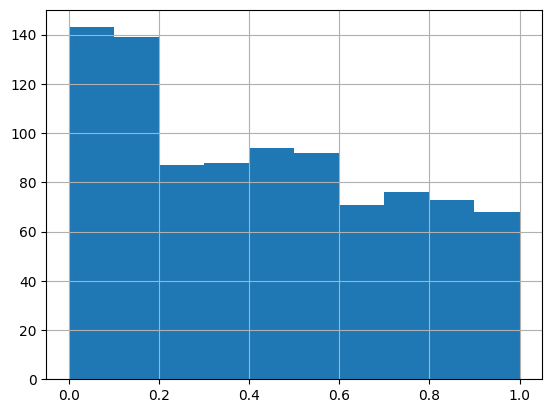

In [855]:
igg_hvg_spearman_df['p_value'].hist()

<Axes: >

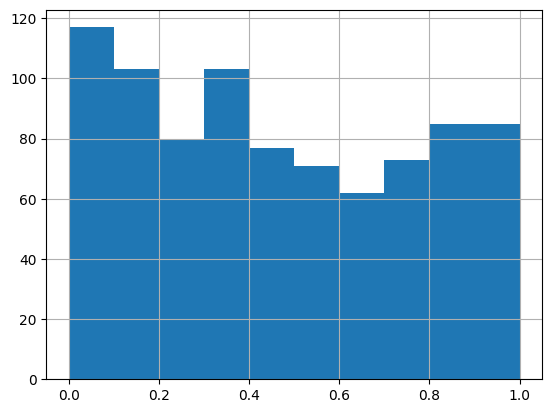

In [856]:
atrem_hvg_spearman_df['p_value'].hist()

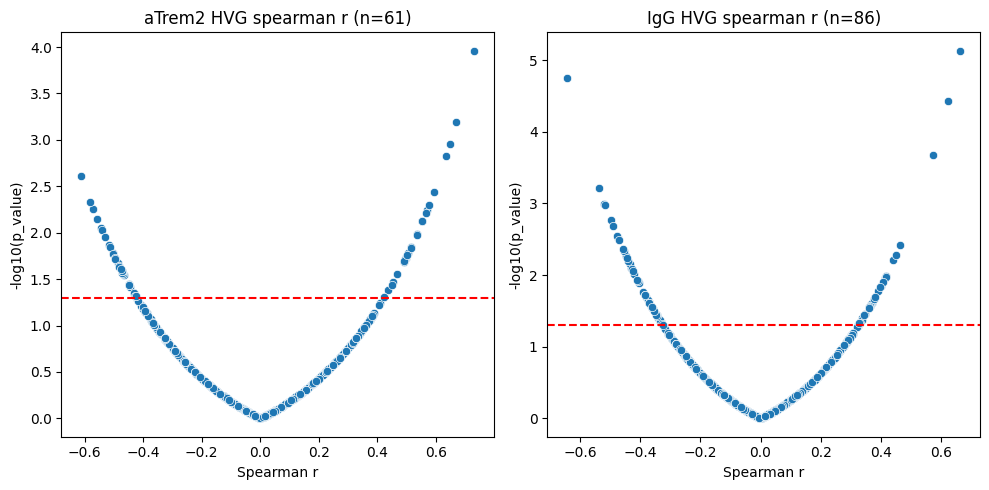

In [857]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for i, (name, df) in enumerate(({"aTrem2":atrem_hvg_spearman_df, "IgG":igg_hvg_spearman_df}).items()):
    sns.scatterplot(data=df, x='spearman_r', y='-log10(p_value)', ax=ax[i])
    ax[i].axhline(y=-np.log10(0.05), color='red', linestyle='--')
    ax[i].set_xlabel('Spearman r')
    ax[i].set_ylabel('-log10(p_value)')
    ax[i].set_title(f'{name} HVG spearman r (n={df.query("p_value < 0.05").shape[0]})')
plt.tight_layout()
plt.show()


In [907]:
from scipy.stats import zscore
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d

def plot_hvg_spearman_heatmap(hvg_freq_sort_df, hvg_spearman_df, madata, p_thresh=0.05, time_col="cTET"):
    norm = Normalize(vmin=madata.obs.loc[hvg_freq_sort_df.index, time_col].min(), vmax=madata.obs.loc[hvg_freq_sort_df.index, time_col].max())
    sorted_mcs = madata.obs.loc[hvg_freq_sort_df.index].sort_values(time_col).index
    g = sns.clustermap(
        hvg_freq_sort_df.loc[sorted_mcs, hvg_spearman_df.index].apply(zscore).apply(gaussian_filter1d, sigma=1).T, 
        col_cluster=False, col_colors=[
            madata.obs.loc[sorted_mcs, 'metacell_cell_type'].map(myeloid_cell_type_colors),
            madata.obs.loc[sorted_mcs, time_col].apply(lambda x: plt.cm.viridis_r(norm(x)))
        ],
        cmap='rocket'
    )
    plt.show()


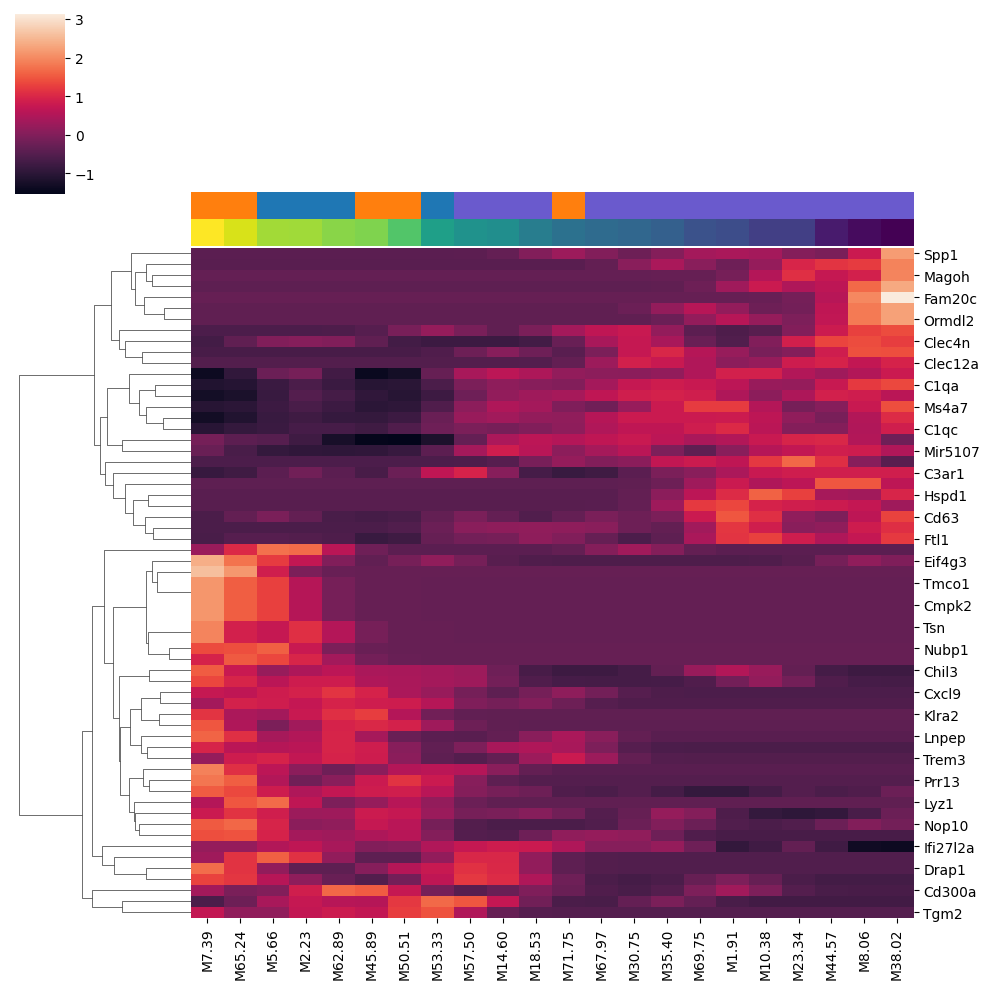

In [908]:
plot_hvg_spearman_heatmap(atrem_hvg_freq_sort_df, atrem_hvg_spearman_df.query('p_value < 0.05'), madata)

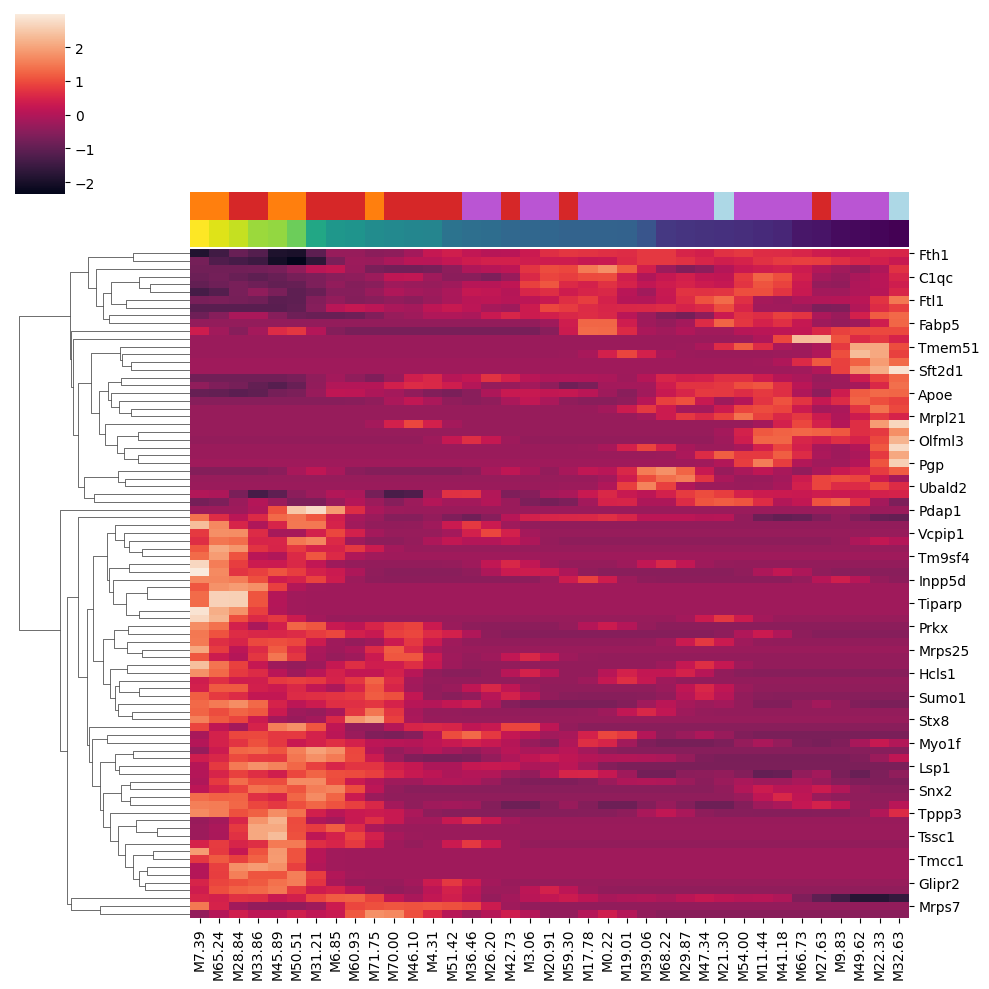

In [909]:
plot_hvg_spearman_heatmap(igg_hvg_freq_sort_df, igg_hvg_spearman_df.query('p_value < 0.05'), madata)

In [863]:
igg_hvg_spearman_fn = "results/06/igg_hvg_spearman_df.naive.csv"
atrem_hvg_spearman_fn = "results/06/atrem_hvg_spearman_df.naive.csv"
atrem_hvg_freq_sort_df.to_csv(atrem_hvg_spearman_fn)
igg_hvg_freq_sort_df.to_csv(igg_hvg_spearman_fn)


## Compare to just binning cells by their time assignment

In [864]:
adata.obs['time_assignment'].value_counts()

time_assignment
Negative        2660
24H             1824
12H             1255
36H             1208
48H              213
Not_Assigned      41
Name: count, dtype: int64

## Compute for individual trajectories/conditions and get new gene sets.

- aTrem
- IgG

In [865]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

def get_cluster_labels(D, k):
    # X is a distance matrix
    clustering = AgglomerativeClustering(n_clusters=k, linkage="ward") # minimize variance within clusters
    clustering.fit(D)
    return clustering.labels_

def get_distance_matrix(mc_data, gene_set, cell_type_col="metacell_cell_type"):
    rho = spearmanr(mc_data[:, gene_set].X.T.toarray())
    d_rho = (rho.statistic + 1) / 2 # following redpath

    # double centering as described in redPath
    def double_center(D):
        row_mean = D.mean(axis=1, keepdims=True)
        col_mean = D.mean(axis=0, keepdims=True)
        grand_mean = D.mean()
        return D - row_mean - col_mean + grand_mean

    centered_d_rho = double_center(d_rho)

    return centered_d_rho


def smooth_auc(mc_data, gene_set, a=0.5, b=0.5, time_col="cTET", cell_type_col="metacell_cell_type"):
    N = mc_data.shape[0]
    # distance matrix, irrespective of the cell type
    D = get_distance_matrix(mc_data, gene_set)
    ref_K = mc_data.obs[cell_type_col].unique().shape[0]
    print(ref_K)

    ks = range(ref_K + 1, N - 1)
    k_cols = [f"k={k}" for k in ks] # already have k=N from individual metacells
    smoothed_auc_df = pd.DataFrame(
        index=mc_data.obs_names, 
        columns=[f"ref_k={ref_K}"] + k_cols
    )
    smoothed_auc_df[cell_type_col] = mc_data.obs[cell_type_col].values
    smoothed_auc_df[time_col] = mc_data.obs[time_col].values
    # first force the cell type
    cell_type_auc = smoothed_auc_df.groupby(cell_type_col)[time_col].mean()
    smoothed_auc_df[f"ref_k={ref_K}"] = smoothed_auc_df[cell_type_col].map(cell_type_auc)

    # then build a tree from the gene set
    for k in ks:
        # get new clustering
        smoothed_auc_df[f"k={k}"] = get_cluster_labels(D, k)
        k_avg_auc = smoothed_auc_df.groupby(f"k={k}")[time_col].mean()
        smoothed_auc_df[f"k={k}"] = smoothed_auc_df[f"k={k}"].map(k_avg_auc)

    smoothed_auc_df[f'smooth_{time_col}'] = b * smoothed_auc_df[k_cols + [time_col]].mean(axis=1) + a * smoothed_auc_df[f"ref_k={ref_K}"]
    return smoothed_auc_df 




In [910]:
atrem_smoothed_auc_df = smooth_auc(
    madata[madata.obs.query('metacell_cell_type in @atrem_mo_types').index, :], 
    madata.var['highly_variable']
)
igg_smoothed_auc_df = smooth_auc(
    madata[madata.obs.query('metacell_cell_type in @igg_mo_types').index, :], 
    madata.var['highly_variable']
)

3


/tmp/ipykernel_1659146/3197415321.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_type_auc = smoothed_auc_df.groupby(cell_type_col)[time_col].mean()


TypeError: unsupported operand type(s) for *: 'float' and 'Categorical'

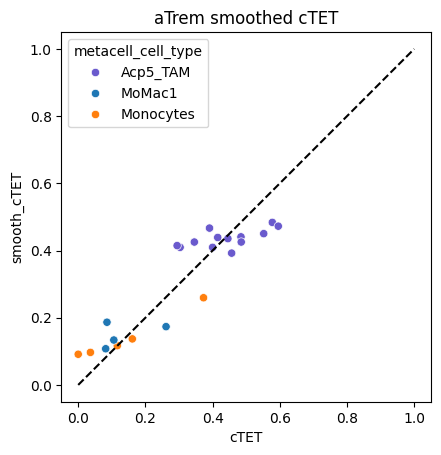

In [911]:
sns.scatterplot(data=atrem_smoothed_auc_df, y='smooth_cTET', x='cTET', hue='metacell_cell_type', palette=myeloid_cell_type_colors)
plt.gca().set_aspect('equal')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('aTrem smoothed cTET')
plt.show()

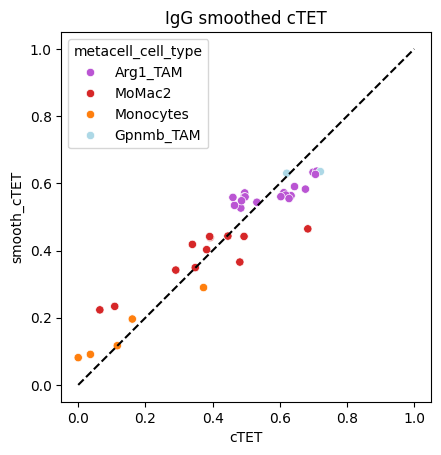

In [867]:
sns.scatterplot(data=igg_smoothed_auc_df, y='smooth_cTET', x='cTET', hue='metacell_cell_type', palette=myeloid_cell_type_colors)
plt.gca().set_aspect('equal')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('IgG smoothed cTET')
plt.show()

In [868]:
madata.obs.loc[atrem_smoothed_auc_df.index, 'smooth_cTET'] = atrem_smoothed_auc_df['smooth_cTET']
madata.obs.loc[igg_smoothed_auc_df.index, 'smooth_cTET'] = igg_smoothed_auc_df['smooth_cTET']


/tmp/ipykernel_1659146/2168614516.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.3922616042027576 0.18659046330429957 0.10765353310859026
 0.09128870979414673 0.4837076949310404 0.4406757420792693
 0.40946655782718494 0.4252537555618273 0.4252843759346898
 0.4094455420993903 0.4388386728624758 0.4724480120745672
 0.45024715531180554 0.11680517471870377 0.13695762481448145
 0.17346284131898435 0.4146862480248356 0.1336190868321055
 0.09680980460876196 0.46676189494421505 0.4354576601471827
 0.2594507709383802]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  madata.obs.loc[atrem_smoothed_auc_df.index, 'smooth_cTET'] = atrem_smoothed_auc_df['smooth_cTET']


In [869]:
smoothed_igg_hvg_spearman_df = get_spearman_df(igg_hvg_freq_sort_df, madata, time_col="smooth_cTET")
smoothed_atrem_hvg_spearman_df = get_spearman_df(atrem_hvg_freq_sort_df, madata, time_col="smooth_cTET")

/tmp/ipykernel_1659146/4253971088.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  s = spearmanr(madata.obs.loc[sort_mcs, time_col].values, hvg_freq_sort_df.loc[sort_mcs, gene].values)
/tmp/ipykernel_1659146/4253971088.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  s = spearmanr(madata.obs.loc[sort_mcs, time_col].values, hvg_freq_sort_df.loc[sort_mcs, gene].values)


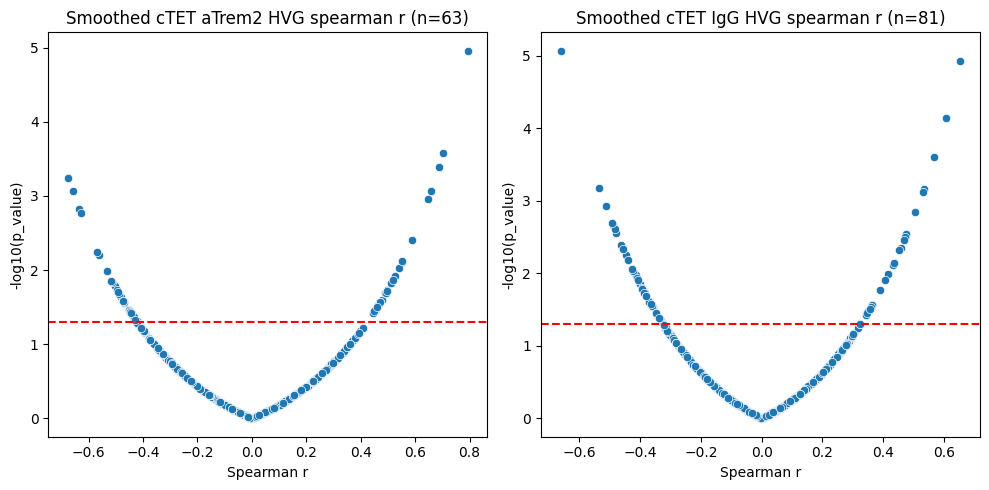

In [870]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for i, (name, df) in enumerate(({"aTrem2":smoothed_atrem_hvg_spearman_df, "IgG":smoothed_igg_hvg_spearman_df}).items()):
    sns.scatterplot(data=df, x='spearman_r', y='-log10(p_value)', ax=ax[i])
    ax[i].axhline(y=-np.log10(0.05), color='red', linestyle='--')
    ax[i].set_xlabel('Spearman r')
    ax[i].set_ylabel('-log10(p_value)')
    ax[i].set_title(f'Smoothed cTET {name} HVG spearman r (n={df.query("p_value < 0.05").shape[0]})')
plt.tight_layout()
plt.show()


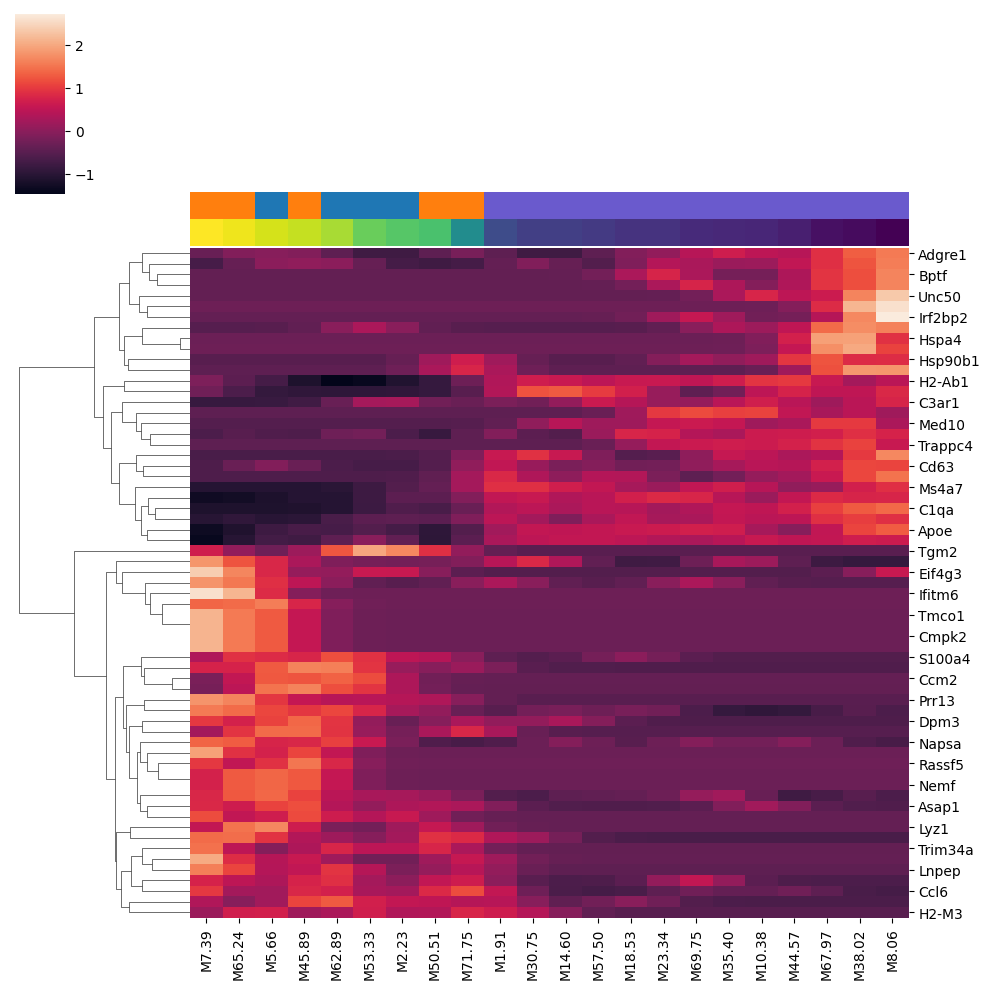

In [912]:
plot_hvg_spearman_heatmap(atrem_hvg_freq_sort_df, smoothed_atrem_hvg_spearman_df.query('p_value < 0.05'), madata, time_col="smooth_cTET")

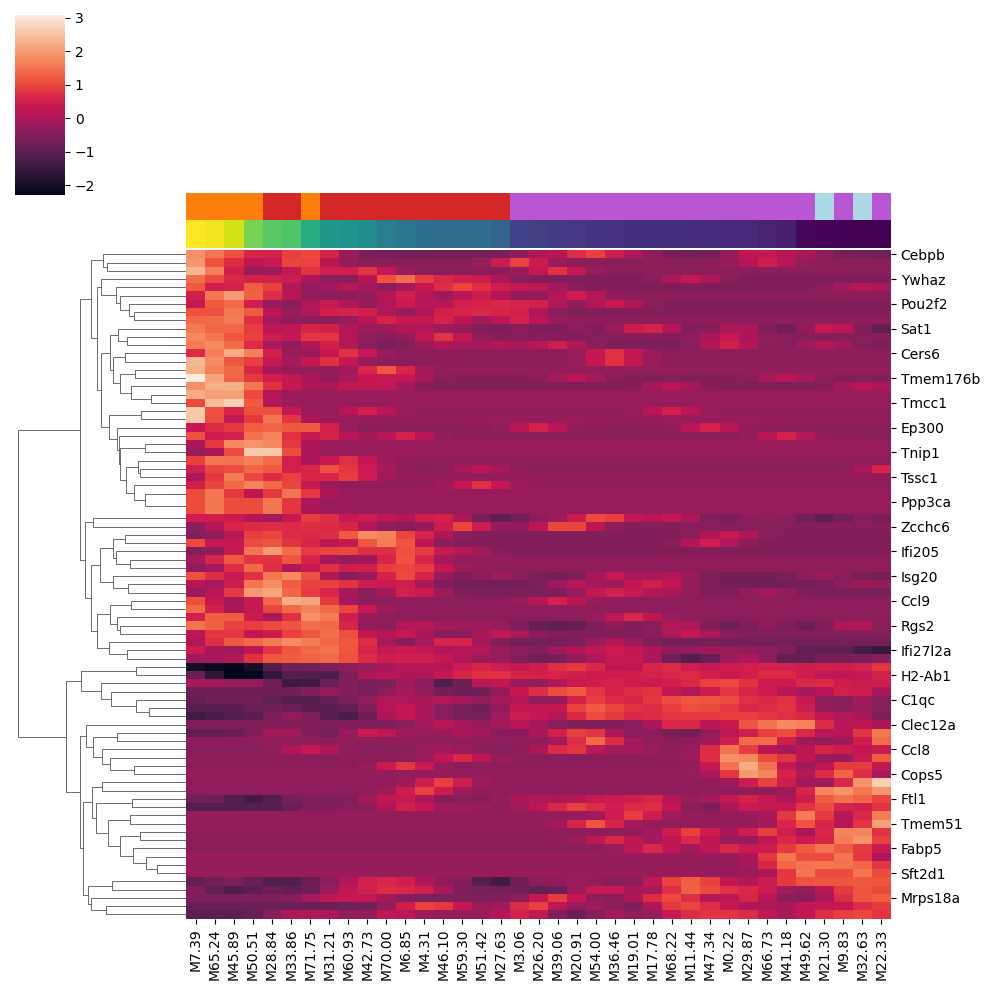

In [913]:
plot_hvg_spearman_heatmap(igg_hvg_freq_sort_df, smoothed_igg_hvg_spearman_df.query('p_value < 0.05'), madata, time_col="smooth_cTET")

Has the effect of making cell types look closer to each other. This also means those markers for thsoe cell states are more likely to be correlated with cTET

In [ ]:
# supplementary table 3
s3_atrem2_corr_fn = "/mnt/thechenlab/ClaudiaC/zmanseq/mmc2.Table_S3_aTREM2_Time.csv"
s3_atrem2_corr_df = pd.read_csv(s3_atrem2_corr_fn)
s3_igg_corr_fn = "/mnt/thechenlab/ClaudiaC/zmanseq/mmc2.Table_S3_Isotype_Control_Time.csv"
s3_igg_corr_df = pd.read_csv(s3_igg_corr_fn)

s3_igg_corr_df['-log10(p_value)'] = -np.log10(s3_igg_corr_df['Pvalue'])
s3_atrem2_corr_df['-log10(p_value)'] = -np.log10(s3_atrem2_corr_df['Pvalue'])


/data/ClaudiaC/envs/zmanr_env/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [874]:
s3_igg_corr_df

,Gene,SpearmanCorrelation,Pvalue,-log10(p_value)
0,Aaas,0.0945,0.536730,0.270244
1,Aacs,0.2120,0.161770,0.791102
2,Aaed1,0.1420,0.350440,0.455386
3,Aagab,-0.0803,0.600110,0.221769
4,Aak1,0.2570,0.088519,1.052964
...,...,...,...,...
11569,n-R5s210,0.3150,0.035162,1.453926
11570,n-R5s41,-0.0890,0.561160,0.250913
11571,n-R5s54,-0.0505,0.741780,0.129725
11572,n-R5s87,0.1830,0.228230,0.641627


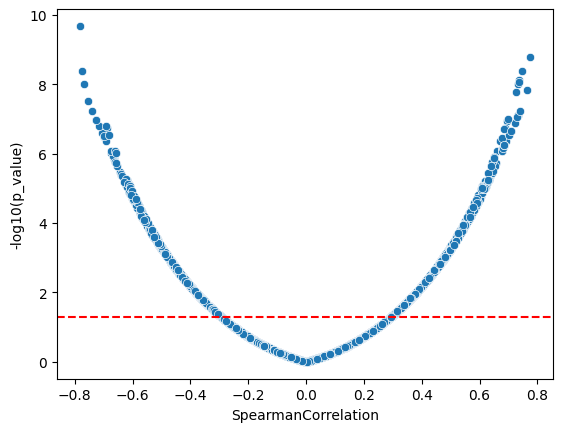

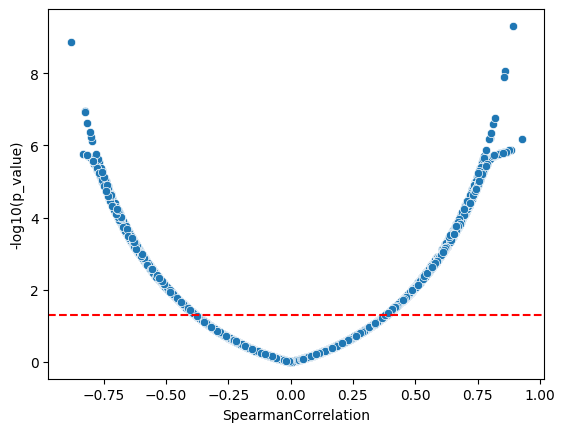

In [875]:
sns.scatterplot(data=s3_igg_corr_df, y='-log10(p_value)', x='SpearmanCorrelation')
plt.axhline(y=-np.log10(0.05), color='red', linestyle='--')
plt.show()
sns.scatterplot(data=s3_atrem2_corr_df, y='-log10(p_value)', x='SpearmanCorrelation')
plt.axhline(y=-np.log10(0.05), color='red', linestyle='--')
plt.show()



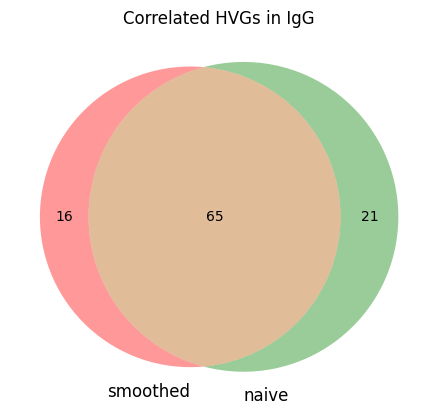

In [876]:
# venn diagram
from matplotlib_venn import venn2
venn2([set(smoothed_igg_hvg_spearman_df.query("p_value < 0.05").index), set(igg_hvg_spearman_df.query("p_value < 0.05").index)], set_labels=('smoothed', 'naive'))
plt.title("Correlated HVGs in IgG")
plt.show()

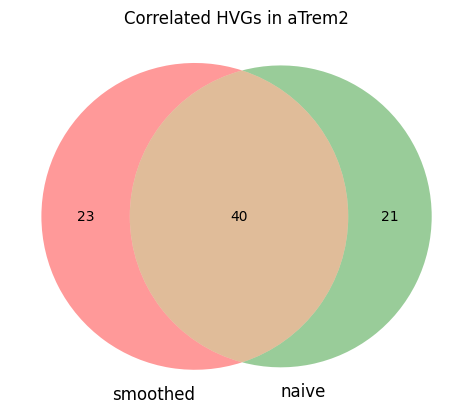

In [877]:
venn2([set(smoothed_atrem_hvg_spearman_df.query("p_value < 0.05").index), set(atrem_hvg_spearman_df.query("p_value < 0.05").index)], set_labels=('smoothed', 'naive'))
plt.title("Correlated HVGs in aTrem2")
plt.show()

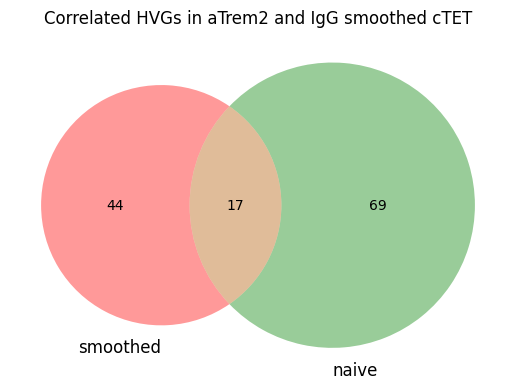

In [878]:
venn2([set(atrem_hvg_spearman_df.query("p_value < 0.05").index), set(igg_hvg_spearman_df.query("p_value < 0.05").index)], set_labels=('smoothed', 'naive'))
plt.title("Correlated HVGs in aTrem2 and IgG smoothed cTET")
plt.show()

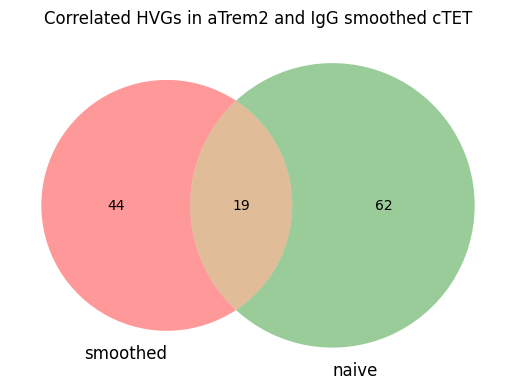

In [879]:
venn2([set(smoothed_atrem_hvg_spearman_df.query("p_value < 0.05").index), set(smoothed_igg_hvg_spearman_df.query("p_value < 0.05").index)], set_labels=('smoothed', 'naive'))
plt.title("Correlated HVGs in aTrem2 and IgG smoothed cTET")
plt.show()

In [880]:
s3_igg_corr_df

,Gene,SpearmanCorrelation,Pvalue,-log10(p_value)
0,Aaas,0.0945,0.536730,0.270244
1,Aacs,0.2120,0.161770,0.791102
2,Aaed1,0.1420,0.350440,0.455386
3,Aagab,-0.0803,0.600110,0.221769
4,Aak1,0.2570,0.088519,1.052964
...,...,...,...,...
11569,n-R5s210,0.3150,0.035162,1.453926
11570,n-R5s41,-0.0890,0.561160,0.250913
11571,n-R5s54,-0.0505,0.741780,0.129725
11572,n-R5s87,0.1830,0.228230,0.641627


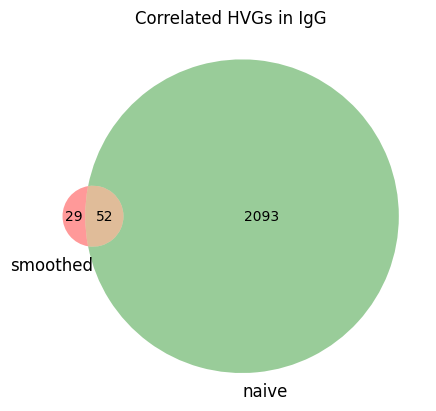

In [881]:
venn2([set(smoothed_igg_hvg_spearman_df.query("p_value < 0.05").index), set(s3_igg_corr_df.query("Pvalue < 0.05")['Gene'])], set_labels=('smoothed', 'naive'))
plt.title("Correlated HVGs in IgG")
plt.show()

In [902]:
def gen_compare_df(smoothed_hvg_spearman_df, s3_corr_df, flip_s3=False):
    gene_intersect = np.intersect1d(smoothed_hvg_spearman_df.index, s3_corr_df['Gene'])
    compare_df = pd.DataFrame(
        index=gene_intersect,
        columns=['smoothed_spearman_r', 's3_spearman_r', 'smoothed_p_value', 's3_p_value'],
    )
    compare_df.loc[gene_intersect, 'smoothed_spearman_r'] = smoothed_hvg_spearman_df.loc[gene_intersect, 'spearman_r']
    compare_df.loc[gene_intersect, 's3_spearman_r'] = s3_corr_df.set_index('Gene').loc[gene_intersect, 'SpearmanCorrelation']
    compare_df.loc[gene_intersect, 'smoothed_p_value'] = smoothed_hvg_spearman_df.loc[gene_intersect, 'p_value']
    compare_df.loc[gene_intersect, 's3_p_value'] = s3_corr_df.set_index('Gene').loc[gene_intersect, 'Pvalue']

    if flip_s3:
        compare_df['s3_spearman_r'] = -compare_df['s3_spearman_r']
    return compare_df

def get_pval_status(r):
    if r['smoothed_p_value'] < 0.05 and r['s3_p_value'] < 0.05:
        return 'both'
    elif r['smoothed_p_value'] < 0.05:
        return 'smoothed'
    elif r['s3_p_value'] < 0.05:
        return 's3'
    else:
        return 'neither'

def plot_compare_df(compare_df):
    compare_df['pval_status'] = compare_df.apply(get_pval_status, axis=1)
    sns.scatterplot(
        compare_df,
        x='smoothed_spearman_r', 
        y='s3_spearman_r',
        hue='pval_status',
        palette={'both': 'black', 'smoothed': 'red', 's3': 'blue', 'neither': 'lightgray'}
    )
    plt.gca().set_aspect('equal')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.axvline(x=0, color='black', linestyle='--')
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title='Pass pval')
    plt.show()


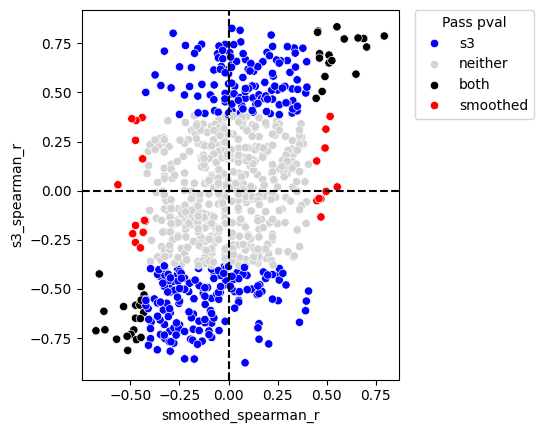

In [903]:
atrem_compare_df = gen_compare_df(smoothed_atrem_hvg_spearman_df, s3_atrem2_corr_df, flip_s3=True)
plot_compare_df(atrem_compare_df)


In [897]:
s3_igg_corr_df.query('Gene == "Sat1"')

,Gene,SpearmanCorrelation,Pvalue,-log10(p_value)
8387,Sat1,0.436,0.00298,2.52574


In [899]:
s3_atrem2_corr_df.query('Gene == "Sat1"')

,Gene,SpearmanCorrelation,Pvalue,-log10(p_value)
8383,Sat1,0.004,0.9842,0.006917


In [901]:
smoothed_igg_hvg_spearman_df.loc['Sat1']

spearman_r        -0.346394
p_value            0.035709
-log10(p_value)    1.447228
Name: Sat1, dtype: object

In Figure 4D Sat1 is negatively correlated with cTET? Unless they define it in the opposite direction. But their heatmap shows high expression at the beginning

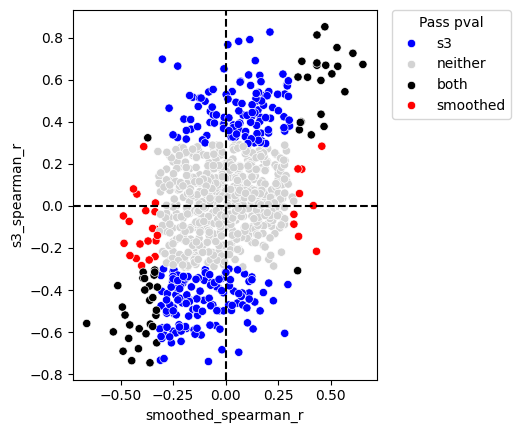

In [904]:
igg_compare_df = gen_compare_df(smoothed_igg_hvg_spearman_df, s3_igg_corr_df, flip_s3=True)
plot_compare_df(igg_compare_df)


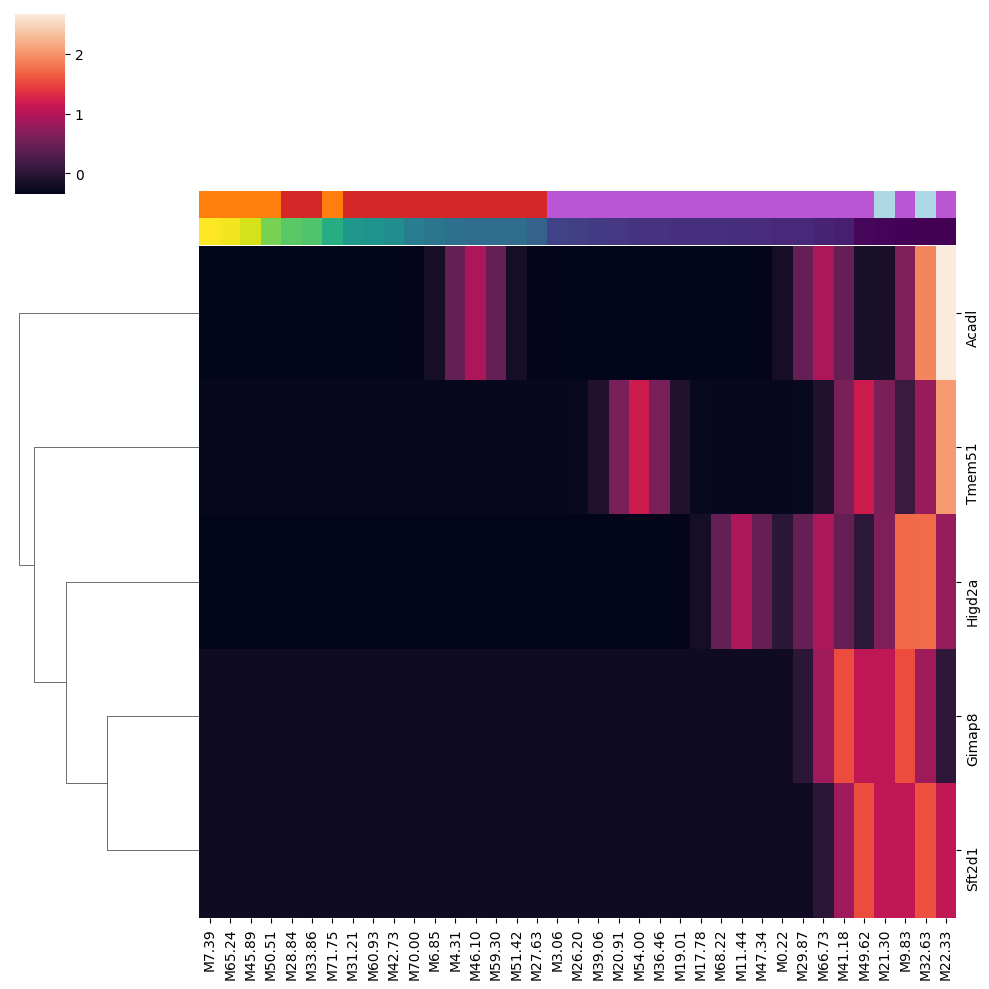

In [924]:
plot_hvg_spearman_heatmap(
    igg_hvg_freq_sort_df, 
    smoothed_igg_hvg_spearman_df.loc[
        igg_compare_df.query('(pval_status == "smoothed" or pval_status == "both") and s3_spearman_r < 0 and smoothed_spearman_r > 0').index
    ], 
    madata, time_col="smooth_cTET"
)

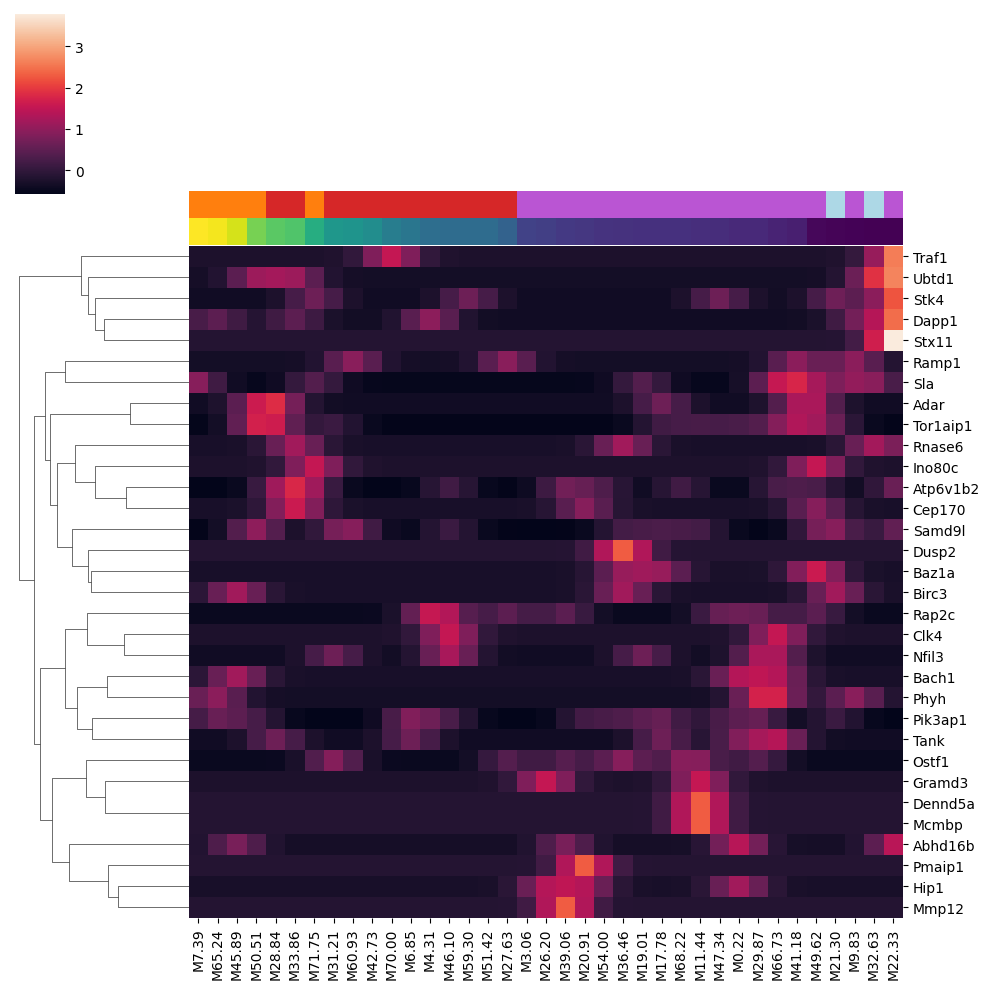

In [921]:
plot_hvg_spearman_heatmap(
    igg_hvg_freq_sort_df, 
    smoothed_igg_hvg_spearman_df.loc[
        igg_compare_df.query('pval_status == "s3" and s3_spearman_r < 0 and smoothed_spearman_r > 0').index
    ], 
    madata, time_col="smooth_cTET"
)

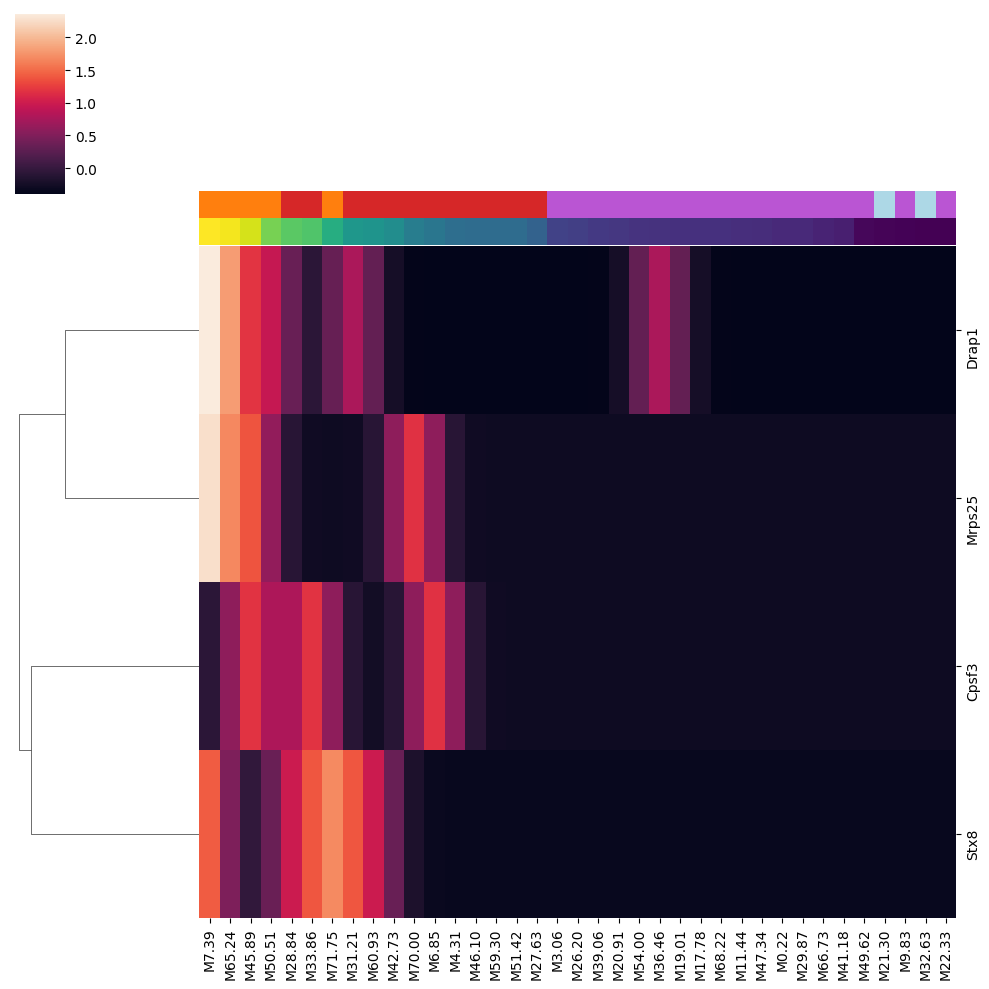

In [922]:
plot_hvg_spearman_heatmap(
    igg_hvg_freq_sort_df, 
    smoothed_igg_hvg_spearman_df.loc[
        igg_compare_df.query('pval_status == "smoothed" and s3_spearman_r > 0 and smoothed_spearman_r < 0').index
    ], 
    madata, time_col="smooth_cTET"
)

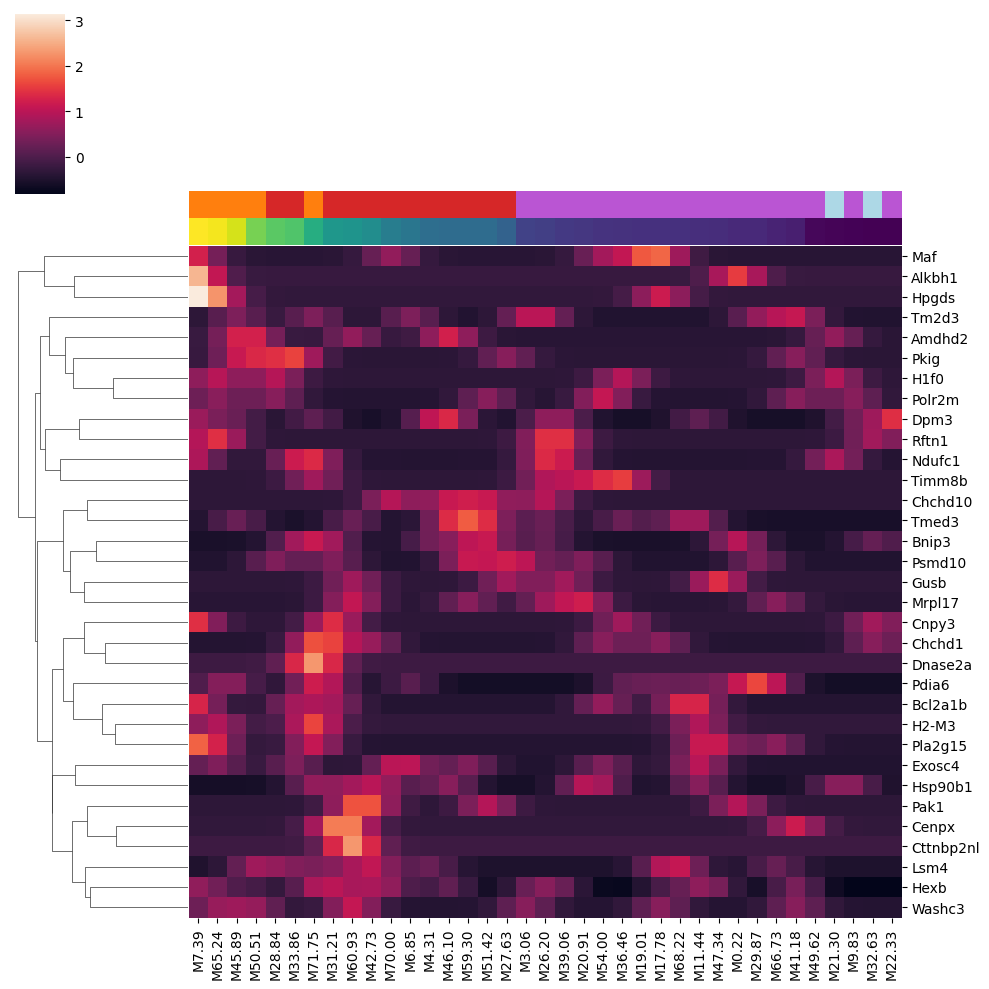

In [923]:
plot_hvg_spearman_heatmap(
    igg_hvg_freq_sort_df, 
    smoothed_igg_hvg_spearman_df.loc[
        igg_compare_df.query('pval_status == "s3" and s3_spearman_r > 0 and smoothed_spearman_r < 0').index
    ], 
    madata, time_col="smooth_cTET"
)

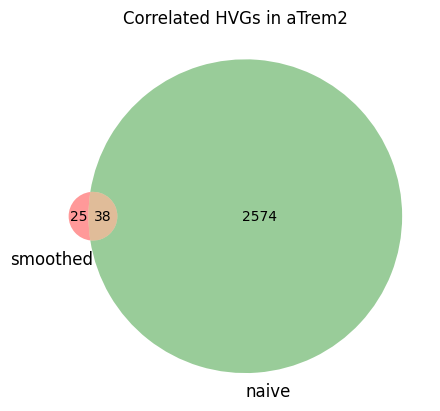

In [844]:
venn2([set(smoothed_atrem_hvg_spearman_df.query("p_value < 0.05").index), set(s3_atrem2_corr_df.query("Pvalue < 0.05")['Gene'])], set_labels=('smoothed', 'naive'))
plt.title("Correlated HVGs in aTrem2")
plt.show()

In [784]:
smoothed_igg_hvg_spearman_fn = "results/06/smoothed_igg_hvg_spearman_df.csv"
smoothed_atrem_hvg_spearman_fn = "results/06/smoothed_atrem_hvg_spearman_df.csv"
smoothed_igg_hvg_spearman_df.to_csv(smoothed_igg_hvg_spearman_fn)
smoothed_atrem_hvg_spearman_df.to_csv(smoothed_atrem_hvg_spearman_fn)


In [787]:
madata.obs.query('metacell_cell_type in @atrem_mo_types').shape

(22, 26)

In [788]:
madata.obs.query('metacell_cell_type in @igg_mo_types').shape

(37, 26)

In [792]:
madata.obs['metacell_cell_type'].value_counts()

metacell_cell_type
Arg1_TAM     18
Acp5_TAM     13
MoMac2       12
cDC2         10
Monocytes     5
MoMac1        4
MonDC         4
Gpnmb_TAM     2
cDC1          2
MigDC         2
Name: count, dtype: int64

In [819]:
for c in ['12H', '24H', '36H', 'AUC', 'norm_AUC', 'cTET', 'smooth_cTET']:
    madata.obs[c] = madata.obs[c].astype(float)

In [820]:
annot_madata_fn = f"results/06/zmanseq_momac_metacells_annot.h5ad"
momac_madata = madata[madata.obs.query('metacell_cell_type in @atrem_mo_types or metacell_cell_type in @igg_mo_types').index]
print(momac_madata.shape)
momac_madata.write_h5ad(annot_madata_fn)

(54, 27055)
